In [13]:
import pandas as pd
import pickle
import os
from nltk.tokenize import sent_tokenize
import nltk
import re
import string
import itertools
import matplotlib.pyplot as plt
nltk.download('punkt')
import bs4 as bs
import numpy as np
import json
import ast
from functools import reduce
from pathlib import Path
from bs4 import BeautifulSoup
from itertools import chain

plt.rcParams['figure.figsize'] = (10,7)
plt.style.use('ggplot')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chuang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [14]:
# define data directory
directory = Path(r"C:\Users\chuang\OneDrive - International Monetary Fund (PRD)\Faltermeier, Julia's files - FIP Traction of IMF surveillance\temp\data") #'../data/'
raw_xml_directory = Path(r"C:\Users\chuang\OneDrive - International Monetary Fund (PRD)\AI tools\Data\ArticleIV_xml_updated")
directory.exists() and raw_xml_directory.exists()

True

In [15]:
# resume work
df = pd.read_csv(directory/'output/df_aiv.csv')

In [16]:
# Number of rows and columns
print("Shape:", df.shape)
# Show column names
print("Columns:", df.columns.tolist())
# Show first few rows
df.head()

Shape: (1177, 22)
Columns: ['Print ISBN', 'filename_staff', 'text_staff', 'filename_buff', 'text_buff', 'text_sa', 'paragraphs_sa', 'paragraphs_bu', 'buff_verified', 'staff_verified', 'Extract text after ":"', 'Full Title', 'Subtitle', 'Title', 'Primary Country Code', 'Year from title', 'Publication Date', 'has_buff', 'paragraphs_sr', 'paragraphs_av', 'av_uncertain', 'bm_date']


,Print ISBN,filename_staff,text_staff,filename_buff,text_buff,text_sa,paragraphs_sa,paragraphs_bu,buff_verified,staff_verified,...,Subtitle,Title,Primary Country Code,Year from title,Publication Date,has_buff,paragraphs_sr,paragraphs_av,av_uncertain,bm_date
0,9781475514797,C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",NaN,NaN,"<html><body><sec id=""A01lev1sec4"">\n<title>Sta...",['Both the fiscal and external imbalances have...,NaN,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,['Economic activity is expected to pick up mor...,['16.Staff commended the authorities for their...,True,NaN
1,9781475516548,C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec7"">\n<title>Sta...",['The authorities are encouraged to continue p...,['The São Toméan authorities are grateful to F...,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,['The authorities remain fully committed to th...,['27. The authorities stated a clear preferenc...,True,NaN
2,9781475517750,C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec5"">\n<title>Sta...",['47. The Israeli economy is growing at a mode...,['The performance of the economy is solid. The...,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,['1. Israel has been exposed to a series of sh...,['40. The authorities broadly concurred with s...,NaN,NaN
3,9781475518450,C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",NaN,NaN,"<html><body><sec id=""A01lev1sec3"">\n<title>Sta...",['23. Namibia has made impressive strides in e...,NaN,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,['1. Namibia’s economic performance in the las...,['The authorities noted the staff’s view about...,True,NaN
4,9781475518528,C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",C:\Users\xtang2\OneDrive - International Monet...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>STA...",['34. The Luxembourg economy is rebounding. Th...,['The Luxembourg authorities would like to tha...,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,['Agence pour le Developpment de l’Emploi (Lux...,['10. Authorities’ views. The authorities conc...,True,NaN


1. read data - local

In [17]:
df_meta = pd.read_excel(directory/'text_collection'/'IMF_Main_MetaData_20240710_toRan_filtered.xlsx')
# df_meta = pd.read_excel(directory/'IMF_Main_MetaData_20240710_toRan_v2 1.xlsx')
len(df_meta)

1028

In [18]:
df_meta.head()

,S#,Pub Id,Language Key,Print ISBN,PDF ISBN,ePub ISBN,Full Title,"Extract text after "":""",Title,Subtitle,...,Jel Code,Jel Code Text,Subjects / Keywords,IMF Topics,IMF Sub-Topics,IMF Sub-Sub-Topics,IMF Sub-Sub-sub Topics,Paper id,Volume #,Issue #
0,15199,22407,42767,9781498341783,9781498329354,9781498314534,India: Staff Report for The 2015 Article IV Co...,Staff Report for The 2015 Article IV Consulta...,India,Staff Report for The 2015 Article IV Consultation,...,G21;E31;C89;F34;E10;L32,Banks; Depository Institutions; Micro Finance ...,ISCR;CR;net portfolio investment inflow;statut...,NaN,NaN,NaN,NaN,Country Report No. 2015/061,2015,61
1,15211,22417,42779,9781498355100,9781498308977,9781498347549,Belgium: 2015 Article IV Consultation—Staff Re...,2015 Article IV Consultation—Staff Report; an...,Belgium,2015 Article IV Consultation—Staff Report; and...,...,E62;K42;G21;H24;J01;E24;E25,Fiscal Policy;Illegal Behavior and the Enforce...,ISCR;CR;government;expenditure measure;economy...,NaN,NaN,NaN,NaN,Country Report No. 2015/070,2015,70
2,15234,22439,42802,9781475531527,9781475545265,9781475599695,Ireland: Staff Report for the 2015 Article IV ...,Staff Report for the 2015 Article IV Consulta...,Ireland,Staff Report for the 2015 Article IV Consultation,...,G21;H63;E50;J30;E43;E52,Banks; Depository Institutions; Micro Finance ...,ISCR;CR;bank bond bond yield;market;benchmark ...,NaN,NaN,NaN,NaN,Country Report No. 2015/077,2015,77
3,15239,22444,42807,9781475552546,9781484302378,9781484301043,Romania: Staff Report for the 2015 Article IV ...,Staff Report for the 2015 Article IV Consulta...,Romania,Staff Report for the 2015 Article IV Consultation,...,E62;G21;H63;E31;E25;H50,Fiscal Policy;Banks; Depository Institutions; ...,ISCR;CR;revenue shortfall;spending restraint;r...,NaN,NaN,NaN,NaN,Country Report No. 2015/079,2015,79
4,15252,22458,42821,9781475517408,9781484310823,9781484310267,Qatar: Staff Report for the 2015 Article IV Co...,Staff Report for the 2015 Article IV Consulta...,Qatar,Staff Report for the 2015 Article IV Consultation,...,Q41;H54;R30;H50;G21;E31;K42,Energy: Demand and Supply; Prices;National Gov...,ISCR;CR;year-on-year inflation data;data;Tier ...,NaN,NaN,NaN,NaN,Country Report No. 2015/086,2015,86


In [19]:
# 1.1. create dataframe from folders
# - get a filtered version of article iv xml files 
# need to check what is the difference between v2 and v5 
folder_dict = {}
for root, dirs, files in os.walk(raw_xml_directory/'results_v2', topdown=False):
    for name in dirs:
        if 'spr_isr' not in name:
            folder_dict[name] = os.path.join(root, name)
for root, dirs, files in os.walk(raw_xml_directory/'results_v5', topdown=False):
    for name in dirs:
        if 'spr_isr' not in name:
            folder_dict[name] = os.path.join(root, name)

print(len(folder_dict))
folder_dict['9781475514797']

1177


'C:\\Users\\chuang\\OneDrive - International Monetary Fund (PRD)\\AI tools\\Data\\ArticleIV_xml_updated\\results_v2\\spr_isr_com_articleiv_2014\\9781475514797'

In [20]:
# Matches "staff appraisal" with minor spelling variations like "appraisal"/"apprasal" and "appraisal"
STAFF_APPRAISAL_RE = re.compile(r"staff app?rai?sal", re.I)
# Matches lines that START with "statement by ..." or "statement on ..."
# (Not used in this function, but kept here for context.)
STATEMENT_RE = re.compile(r"^statement (by|on)\b", re.I)

def extract_staff_appraisal(soup):
    secs = soup.find_all('sec')
    for s in secs:
        title = s.find('title')
        if title and STAFF_APPRAISAL_RE.search(title.get_text(strip=True)):
            # remove unwanted tags
            for tag in s.select('fig, table-wrap'):
                tag.decompose()

            # trim to last numbered paragraph
            numbered = [p for p in s.find_all('p') if p.get_text(strip=True)[:1].isdigit()]
            if numbered:
                last = numbered[-1]
                # remove everything after last
                # delete every sibling node that comes **after** that paragraph,
                # effectively trimming the section to end at this last numbered paragraph
                for el in list(last.next_siblings):
                    el.extract()

            # collect text
            paras = [p.get_text() for p in s.find_all('p')]
            lists = list(chain.from_iterable(
                li.get_text().split('\n') for li in s.find_all('list')
            ))
            lists = [x for x in lists if x.strip()]
            return str(s), paras + lists
    return None, None

In [22]:
def extract_buff_statement(soup):
    """  Extract a list of paragraph texts that belong to a “Statement by/on …” section. """
    body = soup.find('body')
    if not body:
        return None

    # Path 1: article-title contains 'statement by/on'
    titles = body.find_all('article-title')
    if any('statement by' in t.get_text(strip=True).lower() or
           'statement on' in t.get_text(strip=True).lower() for t in titles):
        return [p.get_text() for p in body.find_all('p') if p.get_text(strip=True)]

    # Path 2: first <p> starts with 'statement by'
    p = next((p for p in soup.find_all('p')
              if STATEMENT_RE.match(p.get_text(strip=True).lower())), None)
    if p:
        return [x.get_text() for x in p.find_all_next('p') if x.get_text(strip=True)]

    return None

In [24]:
def process_folders(folder_dict, max_folders=10):
    staff_dict = {}
    staff_content_dict = {}
    text_sa_dict = {}
    para_sa_dict = {}
    buff_dict = {}
    buff_content_dict = {}
    para_bu_dict = {}

    for count, (folder, path) in enumerate(folder_dict.items(), start=1):
        if count > max_folders:
            break

        for root, _, files in os.walk(path):
            files_sorted = sorted(files)
            # First pass: Staff Appraisal
            for fname in files_sorted:
                if 'A00' not in fname or folder in staff_dict:
                    continue
                fullpath = os.path.join(root, fname)
                with open(fullpath, encoding='utf-8') as f:
                    raw = f.read()
                soup = BeautifulSoup(raw)#, 'lxml-xml')

                html_sec, paras = extract_staff_appraisal(soup)
                if html_sec:
                    staff_dict[folder] = fullpath
                    staff_content_dict[folder] = raw
                    text_sa_dict[folder] = html_sec
                    para_sa_dict[folder] = paras
                    break

            # Second pass: Statement by/on
            for fname in reversed(files_sorted):
                fullpath = os.path.join(root, fname)
                # Skip same file as staff file
                if folder in staff_dict and staff_dict[folder] == fullpath:
                    continue
                if folder in buff_dict:
                    break

                with open(fullpath, encoding='utf-8') as f:
                    raw = f.read()
                soup = BeautifulSoup(raw) #, 'lxml-xml')
                paras = extract_buff_statement(soup)
                if paras:
                    buff_dict[folder] = fullpath
                    buff_content_dict[folder] = raw
                    para_bu_dict[folder] = paras
                    break

    return (staff_dict, staff_content_dict, text_sa_dict, para_sa_dict,
            buff_dict, buff_content_dict, para_bu_dict)

In [30]:

staff_dict = {}
staff_content_dict = {}
text_sa_dict = {}
para_sa_dict = {}
buff_dict = {}
buff_content_dict = {}
para_bu_dict = {}

count = 0
for folder in folder_dict:
    count += 1
    print(count)
    if count >10:
        break  # stop loop after first iteration for debugging or sampling
    if folder not in staff_dict:
        print(folder)
        for root, dirs, files in os.walk(folder_dict[folder]):
            print(files)
            for i in range(len(files)):
                if 'A00' in sorted(files)[i] and folder not in staff_dict:
                    with open(os.path.join(root, sorted(files)[i]), 'r', encoding='utf-8') as f:
                        temp = f.read()
                    soup = bs.BeautifulSoup(temp)
                    sec_l = soup.find_all('sec')
                    sec = [sec for sec in sec_l if 'staff appraisal' in sec.find('title').text.lower() or 'staff apraisal' in sec.find('title').text.lower()]
                    if len(sec)>0:
                        sec = sec[0]
                        for s in sec.select('fig'):
                            s.extract()
                        for s in sec.select('table-wrap'):
                            s.extract()
                        end = str([l for l in sec.find_all('p') if len(l.text.strip())>0 and l.text.strip()[0].isdigit()][-1])
                        sec = bs.BeautifulSoup(str(sec)[:str(sec).find(end)+len(end)])
                        staff_dict[folder] = os.path.join(root, sorted(files)[i])
                        staff_content_dict[folder] = temp
                        text_sa_dict[folder] = str(sec)
                        para_sa_dict[folder] = [l.text for l in sec.find_all('p')]+[p for p in list(itertools.chain.from_iterable([l.text.split('\n') for l in sec.find_all('list')])) if p.strip()!='']
            for i in range(len(files)-1, 0, -1):
                if i == len([f for f in files if 'A00' in f])-1 or i == len([f for f in files if 'A00' in f]) and folder not in buff_dict and not (folder in staff_dict and staff_dict[folder]==os.path.join(root, sorted(files)[i])):
                    with open(os.path.join(root, sorted(files)[i]), 'r', encoding='utf-8') as f:
                        temp = f.read()
                    soup = bs.BeautifulSoup(temp)
                    for s in soup.select('abstract'):
                        s.extract()
                    if len([a for a in soup.find('body').find_all('article-title') if 'statement by' in a.text.lower() or 'statement on' in a.text.lower()])>0:
                        buff_dict[folder] = os.path.join(root, sorted(files)[i])
                        buff_content_dict[folder] = temp
                        para_bu_dict[folder] = [l.text for l in soup.find('body').find_all('p') if l.text.strip()!='']
                    elif len([p for p in soup.find_all('p') if p.text.lower().strip().startswith('statement by')])>0:
                        buff_dict[folder] = os.path.join(root, sorted(files)[i])
                        buff_content_dict[folder] = temp
                        para_bu_dict[folder] = [l.text for l in [p for p in soup.find_all('p') if p.text.lower().strip().startswith('statement by')][0].find_all_next('p') if l.text.strip()!='']
                        


1
9781475514797
['21209-9781475514797.xml', '21209-9781475514797_A001.xml', '21209-9781475514797_A002.xml', '21209-9781475514797_A003.xml']


c:\ProgramData\Python3\Lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(


2
9781475516548
['21018-9781475516548.xml', '21018-9781475516548_A001.xml', '21018-9781475516548_A002.xml', '21018-9781475516548_A003.xml', '21018-9781475516548_A004.xml', '21018-9781475516548_A005.xml', '21018-9781475516548_A006.xml']
3
9781475517750
['21156-9781475517750.xml', '21156-9781475517750_A001.xml', '21156-9781475517750_A002.xml', '21156-9781475517750_A003.xml', '21156-9781475517750_A004.xml', '21156-9781475517750_A005.xml']
4
9781475518450
['21147-9781475518450.xml', '21147-9781475518450_A001.xml', '21147-9781475518450_A002.xml', '21147-9781475518450_A003.xml', '21147-9781475518450_A004.xml']
5
9781475518528
['21318-9781475518528.xml', '21318-9781475518528_A001.xml', '21318-9781475518528_A002.xml', '21318-9781475518528_A003.xml', '21318-9781475518528_A004.xml']
6
9781475519006
['21184-9781475519006.xml', '21184-9781475519006_A001.xml', '21184-9781475519006_A002.xml', '21184-9781475519006_A003.xml']
7
9781475528237
['21273-9781475528237.xml', '21273-9781475528237_A001.xml', 

In [33]:
para_bu_dict


{'9781475516548': ['The São Toméan authorities are grateful to Fund Staff for the constructive discussions held in São Tomé and Washington D.C during the 2013 Article IV consultations and second ECF review in September and October 2013. The policy discussions focused on the need to maintain fiscal and external debt sustainability in light of reduced oil prospects, strengthen the resilience of the economy, and reduce financial sector vulnerabilities. My authorities remain committed to consolidate the progress achieved over the years in strengthening economic growth and macroeconomic stability. They broadly concur with the main policy recommendations of the staff report which will help them implement their National Poverty Reduction Strategy Paper II.',
  '1. Recent Economic Developments and Performance under the ECF Arrangement',
  'The economy of São Tomé and Príncipe has been impacted negatively by the global economic slowdown affecting many of the country’s key development and invest

In [ ]:
df = pd.DataFrame([staff_dict, staff_content_dict, buff_dict, buff_content_dict, text_sa_dict, para_sa_dict, para_bu_dict]).T
df = df.reset_index()
df = df[df['index'].apply(lambda x: not x.startswith('spr_'))]
df = df.rename(columns={'index':'Print ISBN', 0:'filename_staff', 1: 'text_staff', 2: 'filename_buff', 3: 'text_buff', 4: 'text_sa', 5: 'paragraphs_sa', 6: 'paragraphs_bu'})

df['buff_verified'] = df['paragraphs_bu'].apply(lambda x: x==x and len(x)>0)
df['staff_verified'] = df['paragraphs_sa'].apply(lambda x: x==x and len(x)>0)

df_meta['Print ISBN'] = df_meta['Print ISBN'].apply(lambda x: str(x))
df = df.merge(df_meta[['Print ISBN', 'Extract text after ":"', 'Full Title', 'Subtitle', 'Title', 'Primary Country Code', 'Year from title', 'Publication Date']], on='Print ISBN', how='left')
for t in ['Extract text after ":"', 'Full Title', 'Subtitle']:
    df[t] = df[t].fillna('')
df['title_all'] = df.apply(lambda x: ', '.join([x['Extract text after ":"'], x['Full Title'], x['Subtitle']]), axis=1)
df.loc[df[df['title_all'].apply(lambda x: x==x and 'statement by' in x.lower())].index, 'has_buff'] = 1
df.loc[df[(df['has_buff']!=1)&(df['buff_verified']==1)&(df['paragraphs_bu'].apply(lambda x: 'does not alter' in ' '.join(x).lower() or 'does not change' in ' '.join(x).lower() if x==x else False))].index, 'paragraphs_bu'] = np.nan
df['buff_verified'] = df['paragraphs_bu'].apply(lambda x: x==x and len(x)>0)

df.loc[df[df['Print ISBN']=='9781484334850'].index, 'Year from title'] = 2017
df.loc[df[df['Print ISBN']=='9781475564082'].index, 'Year from title'] = 2016
df.loc[df[df['Print ISBN']=='9781484334980'].index, 'Year from title'] = 2017
df.loc[df[df['Print ISBN']=='9781616356767'].index, 'Year from title'] = 2021

df.drop('title_all', axis=1, inplace=True)

In [709]:
len(df[df['staff_verified']]), len(df), len(df[df['buff_verified']]), len(df[df['has_buff']==1])

(1176, 1177, 870, 723)

In [710]:
# 2. get additional paragraphs from staff reports
for j, row in df.iterrows():
    if j >= 0 and row['text_staff']==row['text_staff']:
        text_l = []
        staff_l = []
        authority_l = []
        
        soup = bs.BeautifulSoup(row['text_staff'])
        for s in soup.select('fig'):
            s.extract()
        for s in soup.select('table-wrap'):
            s.extract()
        for s in soup.select('boxed-text'):
            s.extract()
            
        # # key issues
        # key_issues = [s for s in soup.find_all('sec', {'sec-type':'contents'}) if 'key issues' in s.find('title').text.lower()][0].find_all('p')
        # staff_l += key_issues[:[i for i in range(len(key_issues)) if key_issues[i].text.strip().lower().startswith('approved by')][0]]
        
        # other paragraphs
        sec_l = soup.find_all('sec')
        try:
            start = [i for i in range(len(sec_l)) if sec_l[i].find('title').text.lower()=='contents'][0]+1
        except Exception:
            start = 0
        end = [i for i in range(len(sec_l)) if 'staff appraisal' in sec_l[i].find('title').text.lower() or 'staff apraisal' in sec_l[i].find('title').text.lower()][0]
        sec_l = sec_l[start:end]
        for sec in sec_l:
            if len(sec.find_all('sec'))==0 and sec not in text_l:
                text_l.append(sec)
            else:
                text_l += [s for s in sec.find_all('sec') if s not in text_l]
                for s in sec.find_all('sec'):
                    s.extract()
                if sec.text.strip() != '' and sec not in text_l:
                    text_l.append(sec)
                
        if len([sec for sec in text_l if sec.find('title') != None and 'authorit' in sec.find('title').text.lower()]) > 0:
            rule_type = 0
        elif len([p for p in sec.find_all('p') for sec in text_l if p.find('bold') != None and p.find('bold').text.lower().startswith('authorit') and p.text.lower().replace('’','').replace("'",'').strip() not in ["authorities views", "authorities view"]]) > 0:
            rule_type = 1
        elif len([p for p in sec.find_all('p') for sec in text_l if p.find('bold') != None and p.text.lower().replace('’','').replace("'",'').strip() in ["authorities views", "authorities view"]]) > 0:
            rule_type = 3
        else:
            rule_type = 2
            
        # Rule: eg. botswana 2021 (806); peru 2021 (820); Uzbekistan 2021 (801)
        if rule_type == 0:
            for sec in text_l:
                if sec.find('title') != None and 'authorit' in sec.find('title').text.lower():
                    authority_l += sec.find_all('p')
                else:
                    staff_l += sec.find_all('p')
        
        # Rule: eg. china 2015 (174)
        elif rule_type == 1:
            for sec in text_l:    
                p_l = sec.find_all('p')
                if len(p_l) > 0:
                    for p in p_l:
                        if p.find('bold') != None and p.find('bold').text.lower().startswith('authorit'):
                            authority_l.append(p)
                        else:
                            staff_l.append(p)
        
        # Rule: eg. aruba 2017 (262)
        elif rule_type == 3:
            for sec in text_l:    
                p_l = sec.find_all('p')
                if len(p_l) > 0:
                    for i in range(len(p_l)):
                        p = p_l[i]
                        if p.find('bold') != None and p.text.lower().replace('’','').replace("'",'').strip() in ["authorities views", "authorities view"]:
                            authority_l.append(p_l[i+1])
                        elif p not in authority_l:
                            staff_l.append(p)
                            
        # Rule: eg. Lithuania 2021 (843)
        else:
            for sec in text_l:
                p_l = sec.find_all('p')
                if len(p_l) > 0:
                    staff_l += p_l[:-1]
                    if p_l[-1].find('bold') != None and 'authorit' in p_l[-1].find('bold').text.lower():
                        authority_l.append(p_l[-1])
                    else:
                        staff_l.append(p_l[-1])
            
        df.loc[j, 'paragraphs_sr'] = str([p.text for p in staff_l])
        df.loc[j, 'paragraphs_av'] = str([p.text for p in authority_l])
        if rule_type == 2:
            df.loc[j, 'av_uncertain'] = True

C:\ProgramData\Python3\Lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(


In [9]:
# # check missing data
# df_meta[df_meta['Print ISBN'].apply(lambda x: str(x) not in folder_dict)]#.to_excel(directory+'output/aiv_missing_v2.xlsx', index=False)

In [6]:
# # 1.2. further filter - read structure from texts
# text_sa_l = []
# para_sa_l = []
# for i, row in df[df['staff_verified']].iterrows():
#     soup = bs.BeautifulSoup(row['text_staff'])
#     sec_l = soup.find_all('sec')
#     try:
#         sec = [sec for sec in sec_l if 'staff appraisal' in sec.find('title').text.lower() or 'staff apraisal' in sec.find('title').text.lower()][0]
#         for s in sec.select('fig'):
#             s.extract()
#         for s in sec.select('table-wrap'):
#             s.extract()
#         text_sa_l.append(sec)
#         para_sa_l.append([l.text for l in sec.find_all('p')]+[p for p in list(itertools.chain.from_iterable([l.text.split('\n') for l in sec.find_all('list')])) if p.strip()!=''])
#     except Exception:
#         text_sa_l.append(np.nan)
#         para_sa_l.append([])

# df['text_sa'] = np.nan
# df['paragraphs_sa'] = [[]]*len(df)
# for j in range(len(text_sa_l)):
#     df.at[df[df['staff_verified']].index[j], 'text_sa'] = str(text_sa_l[j])
#     df.at[df[df['staff_verified']].index[j], 'paragraphs_sa'] = para_sa_l[j]

C:\ProgramData\Python3\lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(


In [7]:
# para_bu_l = []
# for i, row in df[df['buff_verified']].iterrows():
#     soup = bs.BeautifulSoup(row['text_buff'])
#     if len([a for a in soup.find('body').find_all('article-title') if 'statement by' in a.text.lower()])>0:
#         para_bu_l.append([l.text for l in soup.find('body').find_all('p') if l.text.strip()!=''])
#     else:
#         para_bu_l.append([])
# df['paragraphs_bu'] = [[]]*len(df)
# for j in range(len(para_bu_l)):
#     df.at[df[df['buff_verified']].index[j], 'paragraphs_bu'] = para_bu_l[j]

C:\ProgramData\Python3\lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(


In [9]:
# # 1.3. deal with the empty documents
# for folder in folder_dict:
#     if folder not in set(df[df['staff_verified']==True]['Print ISBN']) and 'spr_isr' not in folder:
#         for root, dirs, files in os.walk(folder_dict[folder]):
#             for i in range(len(files)):
#                 if 'A00' in sorted(files)[i]:
#                     with open(os.path.join(root, sorted(files)[i]), 'r', encoding='utf-8') as f:
#                         temp = f.read()
#                     soup = bs.BeautifulSoup(temp)
#                     sec_l = soup.find_all('sec')
#                     sec = [sec for sec in sec_l if 'staff appraisal' in sec.find('title').text.lower() or 'staff apraisal' in sec.find('title').text.lower()]
#                     if len(sec)>0:
#                         sec = sec[0]
#                         for s in sec.select('fig'):
#                             s.extract()
#                         for s in sec.select('table-wrap'):
#                             s.extract()
#                         rv = {'filename_staff': os.path.join(root, sorted(files)[i]), 'text_staff': temp, 'text_sa': str(sec), 'paragraphs_sa': [l.text for l in sec.find_all('p')]+[p for p in list(itertools.chain.from_iterable([l.text.split('\n') for l in sec.find_all('list')])) if p.strip()!='']}
#                         if len(df[df['Print ISBN']==folder])>0:
#                             idx = df[df['Print ISBN']==folder].index[0]
#                         else:
#                             idx = len(df)
#                             df.at[idx, 'Print ISBN'] = folder
#                         for key in rv:
#                             df.at[idx, key] = rv[key]

C:\ProgramData\Python3\lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(
C:\ProgramData\Python3\lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup construc

In [10]:
# for folder in folder_dict:
#     if folder not in set(df[df['buff_verified']==True]['Print ISBN']) and 'spr_isr' not in folder:
#         for root, dirs, files in os.walk(folder_dict[folder]):
#             for i in range(len([f for f in files if 'A00' in f])):
#                 if i == len([f for f in files if 'A00' in f])-1:
#                     with open(os.path.join(root, sorted([f for f in files if 'A00' in f])[i]), 'r', encoding='utf-8') as f:
#                         temp = f.read()
#                     soup = bs.BeautifulSoup(temp)
#                     if len([a for a in soup.find('body').find_all('article-title') if 'statement by' in a.text.lower() or 'statement on' in a.text.lower()])>0:
#                         idx = df[df['Print ISBN']==folder].index[0]
#                         rv = {'filename_buff': os.path.join(root, sorted(files)[i]), 'text_buff': temp, 'paragraphs_bu':[l.text for l in soup.find('body').find_all('p') if l.text.strip()!='']}
#                         for key in rv:
#                             df.at[idx, key] = rv[key]
#                     elif len([p for p in soup.find_all('p') if p.text.lower().strip().startswith('statement by')])>0:
#                         idx = df[df['Print ISBN']==folder].index[0]
#                         rv = {'filename_buff': os.path.join(root, sorted(files)[i]), 'text_buff': temp, 'paragraphs_bu':[l.text for l in [p for p in soup.find_all('p') if p.text.lower().strip().startswith('statement by')][0].find_all_next('p') if l.text.strip()!='']}
#                         for key in rv:
#                             df.at[idx, key] = rv[key]

In [29]:
# # # 1.4. further adjustments to the contents
# # df = pd.read_excel(directory+'output/df_aiv_old.xlsx')

# # adjust staff appraisal part
# df['paragraphs_sa'] = [[]]*len(df)
# for i,row in df[(~df['text_sa'].isna())&(df['text_sa']!='nan')].iterrows():
#     sec = bs.BeautifulSoup(row['text_sa'])
#     for s in sec.select('fig'):
#         s.extract()
#     for s in sec.select('table-wrap'):
#         s.extract()
#     end = str([l for l in sec.find_all('p') if len(l.text.strip())>0 and l.text.strip()[0].isdigit()][-1])
#     sec = bs.BeautifulSoup(row['text_sa'][:row['text_sa'].find(end)+len(end)])
#     df.at[i, 'paragraphs_sa'] = [l.text for l in sec.find_all('p')]+[p for p in list(itertools.chain.from_iterable([l.text.split('\n') for l in sec.find_all('list')])) if p.strip()!='']

# # adjust buff statement
# df['paragraphs_bu'] = [[]]*len(df)
# for folder in folder_dict:
#     if not folder.startswith('spr_isr'): 
#         for root, dirs, files in os.walk(folder_dict[str(folder)]):
#             for i in range(len([f for f in files if 'A00' in f])):
#                 if i == len([f for f in files if 'A00' in f])-1:
#                     with open(os.path.join(root, sorted([f for f in files if 'A00' in f])[i]), 'r', encoding='utf-8') as f:
#                         temp = f.read()
#                     soup = bs.BeautifulSoup(temp)
#                     for s in soup.select('abstract'):
#                         s.extract()
#                     if len([a for a in soup.find('body').find_all('article-title') if 'statement by' in a.text.lower() or 'statement on' in a.text.lower()])>0:
#                         idx = df[df['Print ISBN']==folder].index[0]
#                         rv = {'filename_buff': os.path.join(root, sorted(files)[i]), 'text_buff': temp, 'paragraphs_bu':[l.text for l in soup.find('body').find_all('p') if l.text.strip()!='']}
#                         for key in rv:
#                             df.at[idx, key] = rv[key]
#                     elif len([p for p in soup.find_all('p') if p.text.lower().strip().startswith('statement by')])>0:
#                         idx = df[df['Print ISBN']==folder].index[0]
#                         rv = {'filename_buff': os.path.join(root, sorted(files)[i]), 'text_buff': temp, 'paragraphs_bu':[l.text for l in [p for p in soup.find_all('p') if p.text.lower().strip().startswith('statement by')][0].find_all_next('p') if l.text.strip()!='']}
#                         for key in rv:
#                             df.at[idx, key] = rv[key]

C:\ProgramData\Python3\lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(


In [711]:
len(df[(df['staff_verified'])&(df['Full Title']!='')&(~df['Full Title'].isna())]), len(df[(df['buff_verified'])&(df['Full Title']!='')&(~df['Full Title'].isna())]),  len(df[(df['Full Title']!='')&(~df['Full Title'].isna())])

(1019, 756, 1019)

In [86]:
# get board meeting dates
for i, row in df[~df['Full Title'].isna()].iterrows():
    if i >= 801:
        soup = bs.BeautifulSoup(row['text_staff'])
        try:
            sec = soup.find('book-front')
            for p in sec.find_all('p'):
                try:
                    df.loc[i, 'bm_date'] = pd.to_datetime(p.text)
                    break
                except Exception:
                    pass
        except Exception:
            continue

for i, row in df[~df['Full Title'].isna()].iterrows():
    if row['bm_date']!=row['bm_date']:
        df.loc[i,'bm_date'] = pd.to_datetime(row['Publication Date'])

C:\ProgramData\Python3\Lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(


In [107]:
# output
df.to_csv(directory+'output/df_aiv.csv', index=False)

merge with fundamental variables

In [181]:
df = pd.read_csv(directory+'output/df_aiv.csv').rename(columns={'Year from title': 'year'})
df = df[(~df['Full Title'].isna())]
df.loc[df[df['Print ISBN']==9781484334850].index, 'year'] = 2017
df.loc[df[df['Print ISBN']==9781475564082].index, 'year'] = 2016
df.loc[df[df['Print ISBN']==9781484334980].index, 'year'] = 2017
df.loc[df[df['Print ISBN']==9781616356767].index, 'year'] = 2021
df = df[df['year']!=2024]
df['country'] = df['Title'].apply(lambda x: x.replace('—', '-') if ':' not in x else x.split(':')[0].replace('—', '-').replace('’', "'"))

df['bm_date'] = pd.to_datetime(df['bm_date']).dt.to_period('M')
df['ref_date'] = df.apply(lambda x: str(int(x['year']))+'-07', axis=1)
df['year_l'] = df['year'] - 1
df['year_f'] = df.apply(lambda x: x['year']+1 if str(x['bm_date'])>x['ref_date'] else x['year'], axis=1) 

df['year'].value_counts()

year
2019.0    130
2017.0    129
2016.0    125
2021.0    118
2018.0    115
2015.0    113
2022.0    113
2023.0    106
2020.0     32
Name: count, dtype: int64

In [182]:
# 1. merge part of funda
df_funda = pd.read_csv(directory+'macro/fundamentals.csv')

country_dict = {'Republic of Moldova':'Moldova',
 'Republic of Tajikistan':'Tajikistan',
 'Republic of Slovenia':'Slovenia',
 'Republic of Congo':'Congo, Republic of',
 'Guinea- Bissau':'Guinea-Bissau',
 'Kingdom of the Netherlands - Netherlands':'Netherlands',
 'Turkey':'Türkiye',
 'Republic of Türkiye':'Türkiye',
 'Republic of Belarus':'Belarus',
 'Islamic Republic of Afghanistan':'Afghanistan',
 'Kingdom of the Netherlands-Aruba':'Aruba',
 'Kingdom of Lesotho':'Lesotho',
 'Republic of Mozambique':'Mozambique',
 'Kingdom of the Netherlands-the Netherlands':'Netherlands',
 'Republic of Kosovo':'Kosovo',
 'The Kingdom of the Netherlands-Netherlands':'Netherlands',
 'Republic of Korea':'Korea',
 'Kingdom of Eswatini':'Eswatini',
 'United Republic of Tanzania':'Tanzania',
 'Republic of Estonia':'Estonia',
 'Principality of Andorra':'Andorra',
 'Republic of Equatorial Guinea':'Equatorial Guinea',
 'Republic of Nauru':'Nauru',
 'Lao People’s Democratic Republic':'Lao P.D.R.',
 'Republic of Timor-Leste':'Timor-Leste',
 'Kingdom of the Netherlands - Aruba':'Aruba',
 "Cote d'Ivoire":"Côte d'Ivoire",
 'Republic of Madagascar':'Madagascar',
 "People's Republic of China":'China',
 'Russian Federation':'Russia',
 'Republic of Fiji':'Fiji',
 'Democratic Republic of Timor-Leste':'Timor-Leste',
 'Union of the Comoros':'Comoros',
 'Islamic Republic of Mauritania':'Mauritania',
 'Republic of Uzbekistan':'Uzbekistan',
 'The Federal Democratic Republic of Ethiopia':'Ethiopia',
 'Democratic Republic of São Tomé and Príncipe':'São Tomé and Príncipe',
 'Montenegro':'Montenegro, Rep. of',
 'Islamic Republic of Iran':'Iran',
 'Republic of Lithuania':'Lithuania',
 'The Gambia':'Gambia, The',
 'Kingdom of the Netherlands-Netherlands':'Netherlands',
 'Former Yugoslav Republic of Macedonia':'North Macedonia',
 'People’s Republic of China':'China',
 'Republic of North Macedonia':'North Macedonia',
 'Democratic Republic of the Congo':'Congo',
 'The Republic of Moldova':'Moldova',
 'Republic of Poland':'Poland',
 'Republic of Kazakhstan':'Kazakhstan',
 'Republic of the Marshall Islands':'Marshall Islands',
 'Republic of San Marino':'San Marino',
 'Federated States of Micronesia':'Micronesia',
 "The People's Republic of China":'China',
 'The Bahamas':'Bahamas, The',
 'Republic of Latvia':'Latvia',
 'Republic of Armenia':'Armenia',
 "Lao People's Democratic Republic":'Lao P.D.R.',
 'Arab Republic of Egypt':'Egypt',
 'Republic of Croatia':'Croatia',
 'Democratic Republic of São Tomé and Princípe':'São Tomé and Príncipe',
 'Republic of South Sudan':'South Sudan',
 'Kingdom of the Netherlands–the Netherlands':'Netherlands',
 'Republic of Palau':'Palau',
 'Union of Comoros':'Comoros',
 'Côte d’Ivoire':"Côte d'Ivoire",
 'Republic of Serbia':'Serbia',
 'Republic of Azerbaijan':'Azerbaijan',
 'Kingdom of the Netherlands':'Netherlands',
 'Kingdom of Swaziland': 'Eswatini',
 'Euro Area Policies': 'Euro Area',
 "People's Republic of China-Macao Special Administrative Region": 'Macao SAR',
 "People's Republic of China-Hong Kong Special Administrative Region": 'Hong Kong SAR',
 'People’s Republic of China-Macao Special Administrative Region': 'Macao SAR',
 'People’s Republic of China-Hong Kong Special Administrative Region': 'Hong Kong SAR'}
df['country'] = df['country'].apply(lambda x: country_dict[x] if x in country_dict else x)

df_funda = df_funda[(df_funda['year'].apply(lambda x: x>=2014))&(df_funda['Country'].apply(lambda x: x in (set(df['country']))))]
df_funda = df_funda[~df_funda.duplicated(subset=['Country','year'])]

df = df.merge(df_funda.rename(columns={'Country':'country'}), on=['country', 'year'], how='outer')

In [183]:
key_funda_cols = ['bank_debt', 'official_debt_USD', 'total_debt_service',
       'ext_debt_gross', 'govt_debt_net', 'PPP_GDP', 'ArrangementType',
       'InProgram', 'Index', 'Category', 'Currencytype', 'Currencyboard',
       'fixed_currency', 'Currencyunion', 'Description', 'Inflationtarget',
       'MonetaryTarget', 'Exchangerateanchor', 'Other', 'kaopen',
       'ka_open', 'Fuel', 'Commodity_exc_fuel', 'Manufactures', 'Services',
       'Diversified', 'vae', 'pve', 'gee', 'rqe', 'rle', 'cce', 'inflation',
       'potential_GDP', 'real_GDP', 'unemployment', 'CA_Balance', 'EU_dummy',
       'ECCU_dummy']
df_funda['year_f'] = df_funda['year']
df = df.merge(df_funda[['Country', 'year_f']+key_funda_cols].rename(columns={c: 'f_'+c for c in key_funda_cols}), left_on=['country','year_f'], right_on=['Country', 'year_f'], how='left')

In [184]:
# what's left
df[df['Classification'].isna()]['country'].value_counts()

country
Eastern Caribbean Currency Union                       11
Euro Area                                               6
Kingdom of the Netherlands-Curaçao and Sint Maarten     5
Congo                                                   3
Macao SAR                                               3
Kingdom of the Netherlands-Curacao and Sint Maarten     1
Name: count, dtype: int64

Text(0.5, 0, '')

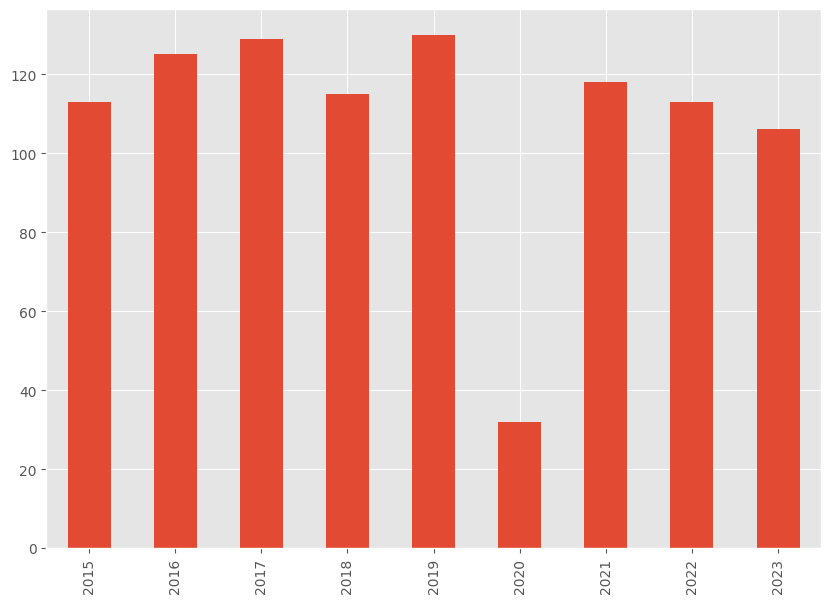

In [185]:
df[(df['staff_verified']==True)]['year'].apply(lambda x: int(x)).value_counts().sort_index().plot.bar()
plt.xlabel('')

In [186]:
df['monetary_sample'] = df.apply(lambda x: x['Category'] not in ['Currency board', 'No separate legal tender'] and x['Currencyunion']!=1 and x['Print ISBN']==x['Print ISBN'], axis=1)
len(df[(df['monetary_sample']==True)]), len(df[(df['staff_verified']==True)&(df['monetary_sample']==True)])

(748, 748)

In [229]:
# IMF related variables (in program, TA, FSAP)
program_l = set(df[df['InProgram']==1]['country'])
df['InProgram_ever'] = df['country'].apply(lambda x: x in program_l)
df['InProgram_after'] = df.apply(lambda x: x['InProgram']==0 and x['country'] in set(df[(df['InProgram']==1)&(df['year']<x['year'])]['country']), axis=1)

df['ta'] = (df['text_staff']+df['text_sa']).apply(lambda x: x==x and 'technical assistance' in x.lower())
program_l = set(df[df['ta']==1]['country'])
df['ta_ever'] = df['country'].apply(lambda x: x in program_l)
df['ta_after'] = df.apply(lambda x: x['ta']==0 and x['country'] in set(df[(df['ta']==1)&(df['year']<x['year'])]['country']), axis=1)

df['fsap'] = (df['text_staff']+df['text_sa']).apply(lambda x: x==x and ('financial sector assessment program' in x.lower() or 'fsap' in x.lower()))
program_l = set(df[df['fsap']==1]['country'])
df['fsap_ever'] = df['country'].apply(lambda x: x in program_l)
df['fsap_after'] = df.apply(lambda x: x['fsap']==0 and x['country'] in set(df[(df['fsap']==1)&(df['year']<x['year'])]['country']), axis=1)

In [190]:
# 2. merge with CPA
df_cpa = pd.read_excel(directory+'macro/cpa.xlsx')
country_dict1 = {'Euro area': 'Euro Area',
 'Andorra, Principality of':'Andorra',
 'Congo, Democratic Republic of the': 'Congo'}
df_cpa['Country'] = df_cpa['Country'].apply(lambda x: country_dict1[x] if x in country_dict1 else x)

for i, row in df[(~df['Print ISBN'].isna())&(df['year']>=2018)].iterrows():
    if str(row['bm_date']) > row['ref_date']:
        temp_date = 'Fall' + ' ' + str(int(row['year']))
    else:
        temp_date = 'Spring' + ' ' + str(int(row['year']))
    if len(df_cpa[(df_cpa['Country']==row['country'])])>0:
        df.loc[i, 'mp_future_buff'] = df_cpa[(df_cpa['Country']==row['country'])&(df_cpa['Indicator']=='CPA_PA_010')][temp_date].iloc[0]
        df.loc[i, 'mp_future_staff'] = df_cpa[(df_cpa['Country']==row['country'])&(df_cpa['Indicator']=='CPA_PA_020')][temp_date].iloc[0]
        df.loc[i, 'fp_future_staff'] = df_cpa[(df_cpa['Country']==row['country'])&(df_cpa['Indicator']=='CPA_PA_050')][temp_date].iloc[0]

['Bahrain',
 'Turkmenistan',
 'Syria',
 'Montserrat',
 'CEMAC',
 'Yemen',
 'Taiwan Province of China',
 'Eritrea',
 'Anguilla',
 'West Bank and Gaza',
 'WAEMU',
 'Venezuela',
 'Puerto Rico']

In [254]:
# 3. global series

# capb
df_capb = pd.read_csv(directory+'macro/capb.csv')
df = df.merge(df_capb[df_capb['COUNTRY.Name']=='Emerging Market and Middle-Income Economies'][['TIME_PERIOD', 'OBS_VALUE']].rename(columns={'TIME_PERIOD':'year', 'OBS_VALUE':'capb_emde'}), how='left')
df = df.merge(df_capb[df_capb['COUNTRY.Name']=='Advanced Economies'][['TIME_PERIOD', 'OBS_VALUE']].rename(columns={'TIME_PERIOD':'year', 'OBS_VALUE':'capb_ae'}), how='left')

# [c for c in set(df_capb['COUNTRY.Name']) if c not in set(df['country'])]
country_dict1 = {'Netherlands, The': 'Netherlands',
 'Russian Federation': 'Russia',
 'Euro Area (EA)': 'Euro Area'}
df_capb['country'] = df_capb['COUNTRY.Name'].apply(lambda x: country_dict1[x] if x in country_dict1 else x)

df = df.merge(df_capb[['TIME_PERIOD', 'country', 'OBS_VALUE']].rename(columns={'TIME_PERIOD':'year', 'OBS_VALUE':'capb'}), how='left')
df_capb['year_f'] = df_capb['TIME_PERIOD']
df = df.merge(df_capb[['country', 'year_f', 'OBS_VALUE']].rename(columns={'OBS_VALUE': 'f_capb'}), how='left')

In [276]:
# fed funds rate
df_ffr = pd.read_csv(directory+'macro/FEDFUNDS.csv')
df_ffr['DATE'] = pd.to_datetime(df_ffr['DATE'])
df_ffr['year'] = df_ffr['DATE'].apply(lambda x: x.year)
df_ffr_yr = df_ffr.groupby('year')[['FEDFUNDS']].mean()
df_ffr_yr['FEDFUNDS_std'] = df_ffr.groupby('year')['FEDFUNDS'].std()
df_ffr_yr = df_ffr_yr.reset_index()
df = df.merge(df_ffr_yr, how='left')

In [290]:
# vix
df_vix = pd.read_csv(directory+'macro/VIXCLS.csv')
df_vix['VIXCLS'] = df_vix['VIXCLS'].apply(lambda x: float(x) if x!='.' else np.nan)
df_vix['DATE'] = pd.to_datetime(df_vix['DATE'])
df_vix['year'] = df_vix['DATE'].apply(lambda x: x.year)
df_vix_yr = df_vix.groupby('year')[['VIXCLS']].mean()
df_vix_yr = df_vix_yr.reset_index()
df = df.merge(df_vix_yr, how='left')

In [305]:
# EPU
df_epu = pd.read_csv(directory+'macro/All_Country_Data(EPU).csv')
df_epu_yr = df_epu.groupby('Year').mean().drop('Month', axis=1).reset_index().rename(columns={'Year': 'year', 'UK': 'United Kingdom',
 'US': 'United States', 'Mainland China': 'China'})
df = df.merge(df_epu_yr[['year', 'GEPU_current', 'GEPU_ppp']], how='left')

# [c for c in df_epu_yr.columns if c not in set(df['country'])]
for c in df_epu_yr.columns:
    if c in set(df['country']):
        df_temp = df_epu_yr[['year', c]]
        for i, row in df_temp.iterrows():
            if len(df[(df['country']==c)&(df['year']==row['year'])]) > 0:
                df.loc[df[(df['country']==c)&(df['year']==row['year'])].index, 'EPU'] = row[c]


In [323]:
# MPU
df_mpu = pd.read_excel(directory+'macro/HRS_MPU_monthly.xlsx')
df_mpu['year'] = df_mpu['Month'].apply(lambda x: int(x.split('m')[0]))
df_mpu_yr = df_mpu.groupby('year')[['US MPU']].mean().reset_index()
df = df.merge(df_mpu_yr, how='left')

In [318]:
# brics
brics_l = ['Brazil', 'Russia', 'India', 'China', 'South Africa']
bricsp_l = ['Brazil', 'Russia', 'India', 'China', 'South Africa', 'Iran', 'Egypt', 'Ethiopia', 'United Arab Emirates']
df['brics_dummy'] = df['country'].apply(lambda x: x in brics_l)
df['bricsplus_dummy'] = df['country'].apply(lambda x: x in bricsp_l)

# us-china tension
df_uct = pd.read_csv(directory+'macro/UCT.csv')
df_uct['year'] = df_uct['date'].apply(lambda x: int(x.split('m')[0]))
df_uct_yr = df_uct.groupby('year')[['UCT']].mean().reset_index()
df = df.merge(df_uct_yr, how='left')

In [335]:
# # 4. external
df_neer = pd.read_excel(directory+'macro/NEER_REER_IMF.xlsx')
# [c for c in set(df_neer['Country']) if c not in set(df['country'])]
country_dict1 = {'Iran, Islamic Rep. of': 'Iran',
 'Congo, Dem. Rep. of the': 'Congo',
 'Central African Rep.': 'Central African Republic',
 'North Macedonia, Republic of': 'North Macedonia',
 'Dominican Rep.': 'Dominican Republic',
 'Fiji, Rep. of': 'Fiji',
 'Czech Rep.': 'Czech Republic',
 'Croatia, Rep. of': 'Croatia',
 'Moldova, Rep. of': 'Moldova',
 'Equatorial Guinea, Rep. of': 'Guinea',
 'Netherlands, The': 'Netherlands',
 'Lesotho, Kingdom of': 'Lesotho',
 'China, P.R.: Hong Kong': 'Hong Kong SAR',
 'Russian Federation': 'Russia',
 'Poland, Rep. of': 'Poland',
 'Armenia, Rep. of': 'Armenia',
 'China, P.R.: Mainland': 'China',
 'Slovak Rep.': 'Slovak Republic'}
df_neer['country'] = df_neer['Country'].apply(lambda x: country_dict1[x] if x in country_dict1 else x)

for i,row in df.iterrows():
    if len(df_neer[df_neer['country']==row['country']])>0 and row['year']<2024:
        df.loc[i, 'neer'] = df_neer[df_neer['country']==row['country']][row['year']].iloc[0]
        df.loc[i, 'd_neer'] = df_neer[df_neer['country']==row['country']][row['year']].iloc[0]/df_neer[df_neer['country']==row['country']][row['year']-1].iloc[0] -1

In [366]:
# election
df_election = pd.read_excel(directory+'macro/election.xlsx')
df_election['Last Election'] = pd.to_datetime(df_election['Last Election'].apply(lambda x: x if x != '-' else np.nan))
df_election['election_year2'] = df_election['Last Election'].apply(lambda x: x.year)
df_election['Cycle'] = df_election['Cycle'].apply(lambda x: int(x.replace(' Years','')) if x==x else np.nan)
df_election['election_year1'] = df_election['election_year2']-df_election['Cycle']
df_election['election_year0'] = df_election['election_year1']-df_election['Cycle']
df_election['election_year3'] = df_election['election_year2']+df_election['Cycle']

# [c for c in set(df['country']) if c not in set(df_election['Country'])]

country_dict1 = {
 'Laos': 'Lao P.D.R.',
 'Cape Verde': 'Cabo Verde',
 'Guinea Bissau': 'Guinea-Bissau',
 "Côte D'Ivoire": "Côte d'Ivoire",
 'Montenegro': 'Montenegro, Rep. of',
 'Democratic Republic of the Congo': 'Congo',
 'United States of America': 'United States',
 'Saint Lucia': 'St. Lucia',
 'Saint Vincent and the Grenadines': 'St. Vincent and the Grenadines',
 'Saint Kitts and Nevis': 'St. Kitts and Nevis',
 'Slovakia': 'Slovak Republic',
 'Gambia': 'Gambia, The',
 'Turkey':'Türkiye',
 'Bahamas':'Bahamas, The',
 'South Korea':  'Korea'}
df_election['country'] = df_election['Country'].apply(lambda x: country_dict1[x] if x in country_dict1 else x)

for i, row in df.iterrows():
    if len(df_election[df_election['country']==row['country']])>0:
        df_temp = df_election[df_election['country']==row['country']].iloc[0]
        for j in range(0,4):
            if row['year']==df_temp['election_year%d'%j]:
                df.loc[i, 'election_years_left'] = 0
                break
            elif j==0 and row['year']<df_temp['election_year%d'%j]:
                df.loc[i, 'election_years_left'] = df_temp['election_year%d'%j]-row['year']
            elif j > 0 and row['year']>df_temp['election_year%d'%(j-1)] and row['year']<df_temp['election_year%d'%(j)]:
                df.loc[i, 'election_years_left'] = df_temp['election_year%d'%j]-row['year']

['Lao P.D.R.',
 'Bahamas, The',
 'Eastern Caribbean Currency Union',
 'Korea',
 'United States',
 'Kyrgyz Republic',
 'Hong Kong SAR',
 'Türkiye',
 'Montenegro, Rep. of',
 'Aruba',
 "Côte d'Ivoire",
 'Slovak Republic',
 'St. Lucia',
 'St. Vincent and the Grenadines',
 'Macao SAR',
 'Gambia, The',
 'Cabo Verde',
 'Kosovo',
 'Kingdom of the Netherlands-Curacao and Sint Maarten',
 'Euro Area',
 'Kingdom of the Netherlands-Curaçao and Sint Maarten',
 'St. Kitts and Nevis',
 'Congo, Republic of',
 'Guinea-Bissau']

In [386]:
# political variables
df_political = pd.read_csv(directory+'macro/DPI2020.csv')
df_political = df_political[['countryname', 'year', 'execrlc', 'polariz', 'stabs', 'allhouse', 'system']]

# [c for c in set(df['country']) if c not in set(df_political['country'])]
# [c for c in set(df_political['country']) if c not in set(df['country'])]
country_dict1 = {
 'Laos': 'Lao P.D.R.',
 'Trinidad-Tobago': 'Trinidad and Tobago',
 'eSwatini':'Eswatini',
 'S. Africa': 'South Africa',
 'Congo (DRC)': 'Congo',
 'UK': 'United Kingdom',
 'Eq. Guinea': 'Equatorial Guinea',
 'Solomon Is.': 'Solomon Islands',
 'Cent. Af. Rep.': 'Central African Republic',
 'PRC': 'China',
 'Comoro Is.':'Comoros',
 'Czech Rep.': 'Czech Republic',
 'Dom. Rep.': 'Dominican Republic',
 'Brunei': 'Brunei Darussalam',
 'C. Verde Is.': 'Cabo Verde',
 'Slovakia': 'Slovak Republic',
 'Swaziland': 'Eswatini',
 'Gambia': 'Gambia, The',
 "Cote d'Ivoire": "Côte d'Ivoire",
 'Bosnia-Herz': 'Bosnia and Herzegovina',
 'USA':'United States',
 'FRG/Germany':'Germany',
 'Bahamas': 'Bahamas, The',
 'Turkey':'Türkiye',
 'ROK': 'Korea',
 'UAE': 'United Arab Emirates',
 'P. N. Guinea':'Papua New Guinea'}
df_political['country'] = df_political['countryname'].apply(lambda x: country_dict1[x] if x in country_dict1 else x)
df = df.merge(df_political.drop('countryname', axis=1), how='left')
df = df[~df.duplicated(subset=['country', 'year'])]

C:\Users\xtang2\AppData\Local\Temp\ipykernel_3796\350220627.py:2: DtypeWarning: Columns (16,20,23,28,32,34,37,41,43,46,50,62,67,94,99) have mixed types. Specify dtype option on import or set low_memory=False.
  df_political = pd.read_csv(directory+'macro/DPI2020.csv')


In [409]:
# commodity price
df_comm = pd.read_csv(directory+'macro/PALLFNFINDEXQ.csv')
df_comm['DATE'] = pd.to_datetime(df_comm['DATE'])
df_comm['year'] = df_comm['DATE'].apply(lambda x: x.year)
df_comm_yr = df_comm.groupby('year')[['PALLFNFINDEXQ']].mean()
df_comm_yr['PALLFNFINDEXQ_std'] = df_comm.groupby('year')['PALLFNFINDEXQ'].std()
df_comm_yr = df_comm_yr.reset_index()
df = df.merge(df_comm_yr, how='left')

In [3]:
df = pd.read_csv(directory+'output/df_aiv_funda.csv')
df = df.drop(['execrlc', 'polariz', 'stabs'], axis=1)

# political variables
df_political = pd.read_csv(directory+'macro/DPI2020.csv')
df_political = df_political[['countryname', 'year', 'execrlc', 'polariz', 'stabs', 'allhouse', 'system']]

# [c for c in set(df['country']) if c not in set(df_political['country'])]
# [c for c in set(df_political['country']) if c not in set(df['country'])]
country_dict1 = {
 'Laos': 'Lao P.D.R.',
 'Trinidad-Tobago': 'Trinidad and Tobago',
 'eSwatini':'Eswatini',
 'S. Africa': 'South Africa',
 'Congo (DRC)': 'Congo',
 'UK': 'United Kingdom',
 'Eq. Guinea': 'Equatorial Guinea',
 'Solomon Is.': 'Solomon Islands',
 'Cent. Af. Rep.': 'Central African Republic',
 'PRC': 'China',
 'Comoro Is.':'Comoros',
 'Czech Rep.': 'Czech Republic',
 'Dom. Rep.': 'Dominican Republic',
 'Brunei': 'Brunei Darussalam',
 'C. Verde Is.': 'Cabo Verde',
 'Slovakia': 'Slovak Republic',
 'Swaziland': 'Eswatini',
 'Gambia': 'Gambia, The',
 "Cote d'Ivoire": "Côte d'Ivoire",
 'Bosnia-Herz': 'Bosnia and Herzegovina',
 'USA':'United States',
 'FRG/Germany':'Germany',
 'Bahamas': 'Bahamas, The',
 'Turkey':'Türkiye',
 'ROK': 'Korea',
 'UAE': 'United Arab Emirates',
 'P. N. Guinea':'Papua New Guinea'}
df_political['country'] = df_political['countryname'].apply(lambda x: country_dict1[x] if x in country_dict1 else x)
df = df.merge(df_political.drop('countryname', axis=1), how='left')
df = df[~df.duplicated(subset=['country', 'year'])]

C:\Users\xtang2\AppData\Local\Temp\ipykernel_23524\457528315.py:5: DtypeWarning: Columns (16,20,23,28,32,34,37,41,43,46,50,62,67,94,99) have mixed types. Specify dtype option on import or set low_memory=False.
  df_political = pd.read_csv(directory+'macro/DPI2020.csv')


In [5]:
df.to_csv(directory+'output/df_aiv_funda.csv', index=False)

2. connect to API / test topic prompts

In [155]:
from openai import OpenAI
client = OpenAI(api_key="sk-proj-fyoBu7GzQG8H6LEq0lPdT3BlbkFJfZqc0U4ZYoIy89R6I2VP")
# client = OpenAI(api_key='sk-None-eGR9kyQrLnY0BzZtfI67T3BlbkFJt8kbEsatG9t8dFMIF4hJ')
# client = OpenAI(api_key="sk-proj-5qzZVEalSawZKz3tQLU1T3BlbkFJW3JlMmi6EKwlqyiNyFT4") # mine

ImportError: DLL load failed while importing jiter: Access is denied.

In [ ]:
# version 3
chat_completion = client.chat.completions.create(
    messages=[
        {   "role": "system",
            "content": '''You are an experience macroeconomist from IMF. Your job is to assign topic labels to a given paragraph from IMF document.
You are given a list of topics with their definition and key indicators as below:
----------------
----------------
1. **Economic Outlook**: The assessment of cyclical position and economic outlook involves evaluating the current and projected state of an economy over various time horizons. This includes analyzing near-term and medium-term growth prospects, understanding the business cycle phases (expansion and contraction), and identifying potential economic risks and uncertainties. Key indicators such as GDP growth, inflation, and the output gap are scrutinized to gauge macroeconomic stability. The evaluation also considers the impacts of fiscal and monetary policies on economic trends and forecasts potential scenarios, highlighting recession risks and opportunities for economic expansion.

2. **Monetary Policy**: Monetary policy refers to the actions undertaken by a central bank to manage the economy by controlling the money supply, interest rates, and inflation. It aims to achieve price stability, full employment, and economic growth. Key aspects include setting the policy rate, managing inflation expectations and targets, addressing inflationary pressures, and ensuring financial stability. Monetary policy can involve conventional measures, such as adjusting interest rates, and unconventional tools, like quantitative easing and monetary tightening. It also encompasses the monetary transmission mechanism, which describes how policy actions affect the economy, and the interaction with fiscal policy.

3. **Fiscal Stance**: The fiscal stance and debt topic encompasses the analysis and evaluation of a government's fiscal policies and their impact on economic sustainability. This includes assessing fiscal sustainability, consolidation efforts, and the overarching fiscal framework that guides policy decisions. Key considerations involve the management of fiscal space, budget allocations, and the balance between fiscal deficits and surpluses. The topic also examines the influence of oil and non-oil revenues on fiscal health, the intricacies of managing government debt, and strategies for ensuring debt sustainability. Understanding the relationship between fiscal policy, expenditure, GDP, and various forms of debt (public, external, and domestic) is crucial for formulating effective economic strategies and maintaining financial stability.

4. **Financial Stability**: Financial stability refers to the resilience of the financial system, including banks, financial markets, and other financial institutions, in withstanding economic shocks and maintaining efficient functioning. It encompasses various aspects such as financial inclusion, risk management, credit growth, and the health of the banking sector. Key elements include the implementation of macroprudential policies, management of non-performing loans (NPLs), maintenance of adequate capital and liquidity levels, and robust supervision and stress testing of financial institutions. Effective governance, rigorous internal and external audits, and adherence to reporting standards and safeguards assessments are essential to ensure financial stability. Regulatory measures and assessment recommendations play a crucial role in sustaining the overall health of the financial system.

5. **External Stance**: The topic covers the macroeconomic analysis of a country's external economic health and the dynamics of its currency's exchange rate. Key elements include international reserves, current account deficits and surpluses, and the effective exchange rate, which are essential indicators of external balance. The topic also encompasses the analysis of implied fundamentals through models like the EBA-lite, and the impact of capital grants, trade policies, and trade elasticities on the external position. Understanding trade liberalization, integration, and barriers further helps in evaluating the broader context of global trade influences on exchange rates.
----------------
----------------

Given a paragraph from a report published by the IMF, please carefully analyze the paragraph and classify the provided paragraph using ONLY the provided topics. Assign a confidence score from 0-100 to each topic label. If the paragraph does not fit into any of the provided topics, assign 100 to "Other" and 0 to the other topics. Try your best to assign a positive score to only one topic for the paragraph. You can use multiple categories only if you are very confident that multiple topics are extensively discussed in the majority of the paragraph. Please provide your reasoning for your classification first, and then assign the confidence scores.

Please respond in a clean json dictionary: \"Reason\", \"Economic Outlook\", \"Monetary Policy\", \"Fiscal Stance\", \"Financial Stability\", \"External Stance\".''',},
        {   "role": "user",
            "content":  "7. The authorities remain committed to fiscal consolidation and view it as a crucial element to ensure sustainability in long run. The authorities note staff’s recommendation that fiscal consolidation should be growth-friendly to contain the rise of public debt, and avoid disorderly adjustment and large cut in capital expenditures. Despite the current target budget deficit of 3.5 percent of GDP, the authorities emphasize the intention to lower the deficit to 3 percent of GDP by 2020. The measures under consideration would include improvement in tax administration and prioritization in social and capital expenditures. With this, the target for public debt is around 64.8% of GDP at end 2017."}
    ],
    model="gpt-4o", 
    temperature=0
)
result = json.loads(chat_completion.choices[0].message.content.replace('```json','').replace('```',''))
result

In [963]:
# # version 2
# chat_completion = client.chat.completions.create(
#     messages=[
#         {   "role": "system",
#             "content": '''You are an experience macroeconomist from IMF. Your job is to assign topic labels to a given paragraph from IMF document.
# You are given a list of topics with their definition and key indicators as below:
# ----------------
# ----------------
# 1. **Economic Outlook**:
# - **Definition**: The assessment of cyclical position and economic outlook involves evaluating the current and projected state of an economy over various time horizons. This includes analyzing near-term and medium-term growth prospects, understanding the business cycle phases (expansion and contraction), and identifying potential economic risks and uncertainties. Key indicators such as GDP growth, inflation, and the output gap are scrutinized to gauge macroeconomic stability. The evaluation also considers the impacts of fiscal and monetary policies on economic trends and forecasts potential scenarios, highlighting recession risks and opportunities for economic expansion.
# - **Key Indicators**: economic outlook, near-term growth, medium-term growth, economic assessment, GDP growth, business cycle, economic forecast, projected growth, output gap, cyclical analysis, economic risks, economic indicators, macroeconomic stability, recession risk, expansion phase, contraction phase, economic trends

# 2. **Monetary Policy**:
# - **Definition**: Monetary policy refers to the actions undertaken by a central bank, such as the Federal Reserve or the European Central Bank, to manage the economy by controlling the money supply, interest rates, and inflation. It aims to achieve price stability, full employment, and economic growth. Key aspects include setting the policy rate, managing inflation expectations and targets, addressing inflationary pressures, and ensuring financial stability. Monetary policy can involve conventional measures, such as adjusting interest rates, and unconventional tools, like quantitative easing and monetary tightening. It also encompasses the monetary transmission mechanism, which describes how policy actions affect the economy, and the interaction with fiscal policy.
# - **Key Indicators**: inflation expectations, inflation target, inflationary pressures, monetary policy stance, policy rate, price stability, interest rates, central bank, quantitative easing, monetary tightening, unconventional monetary policy, monetary transmission mechanism, currency exchange rates, liquidity management, money supply, aggregate demand

# 3. **Fiscal Stance**:
# - **Definition**: The fiscal stance and debt topic encompasses the analysis and evaluation of a government's fiscal policies and their impact on economic sustainability. This includes assessing fiscal sustainability, consolidation efforts, and the overarching fiscal framework that guides policy decisions. Key considerations involve the management of fiscal space, budget allocations, and the balance between fiscal deficits and surpluses. The topic also examines the influence of oil and non-oil revenues on fiscal health, the intricacies of managing government debt, and strategies for ensuring debt sustainability. Understanding the relationship between fiscal policy, expenditure, GDP, and various forms of debt (public, external, and domestic) is crucial for formulating effective economic strategies and maintaining financial stability.
# - **Key Indicators**: fiscal sustainability, fiscal consolidation, fiscal framework, fiscal policy, fiscal space, budget, fiscal deficit, primary deficit, balanced budget, fiscal stance, oil revenue, non-oil revenue, government debt, expenditure, debt sustainability, debt management, external debt, public debt, domestic debt

# 4. **Financial Stability**:
# - **Definition**: Financial stability refers to the resilience of the financial system, including banks, financial markets, and other financial institutions, in withstanding economic shocks and maintaining efficient functioning. It encompasses various aspects such as financial inclusion, risk management, credit growth, and the health of the banking sector. Key elements include the implementation of macroprudential policies, management of non-performing loans (NPLs), maintenance of adequate capital and liquidity levels, and robust supervision and stress testing of financial institutions. Effective governance, rigorous internal and external audits, and adherence to reporting standards and safeguards assessments are essential to ensure financial stability. Regulatory measures and assessment recommendations play a crucial role in sustaining the overall health of the financial system.
# - **Key Indicators**: financial inclusion, financial stability, risk, banking sector, credit growth, financial institutions, macroprudential, non-performing loans (NPLs), capital, credit risk, liquidity, supervision, stress tests, bank governance, internal audit, reporting standards, safeguards assessment, external audit, assessment recommendations, regulatory measures

# 5. **External Stance**:
# - **Definition**: The topic covers the macroeconomic analysis of a country's external economic health and the dynamics of its currency's exchange rate. Key elements include international reserves, current account deficits and surpluses, and the effective exchange rate, which are essential indicators of external balance. The topic also encompasses the analysis of implied fundamentals through models like the EBA-lite, and the impact of capital grants, trade policies, and trade elasticities on the external position. Understanding trade liberalization, integration, and barriers further helps in evaluating the broader context of global trade influences on exchange rates.
# - **Key Indicators**: international reserves, current account deficit, implied fundamentals, external balance, effective exchange rate, current account surplus, EBA-lite model, external deficit, capital grants, exchange rate, import elasticity, export elasticity, trade liberalization, trade policy, trade integration, bilateral trade, global trade, tariff barriers, foreign direct investment (FDI)
# ----------------
# ----------------

# Given a paragraph from a report published by the International Monetary Fund, please carefully analyze the paragraph and classify the provided paragraph using ONLY the provided topics. If the paragraph does not fit into any of the provided topics, assign "Other".
# Try your best to assign only one topic to the paragraph. You can use multiple categories only if you are very confident that multiple topics are extensively discussed in the majority of the paragraph.
# Please provide your reasoning for your classification first, and then provide the topic label and a confidence score from 0-100.

# Please respond in clean json format as follow:
# reasoning: <explanation for topic label >,
# topic_labels: [<topic label: confidence score>,...]''',},
#         {   "role": "user",
#             "content":  "7. The authorities remain committed to fiscal consolidation and view it as a crucial element to ensure sustainability in long run. The authorities note staff’s recommendation that fiscal consolidation should be growth-friendly to contain the rise of public debt, and avoid disorderly adjustment and large cut in capital expenditures. Despite the current target budget deficit of 3.5 percent of GDP, the authorities emphasize the intention to lower the deficit to 3 percent of GDP by 2020. The measures under consideration would include improvement in tax administration and prioritization in social and capital expenditures. With this, the target for public debt is around 64.8% of GDP at end 2017."}
#     ],
#     model="gpt-4o", 
#     temperature=0
# )
# result = json.loads(chat_completion.choices[0].message.content.replace('```json','').replace('```',''))
# result

In [193]:
# # version 1
# chat_completion = client.chat.completions.create(
#             messages=[
#                 {   "role": "system",
#                     "content": '''You are an experience macroeconomist from IMF. Your job is to assign topic labels to a given paragraph from IMF document.
# You are given a list of topics with their definition and key indicators as below:
# ----------------
# ----------------
# 1. **Real Sector**:
#    - **Definition**: The real sector encompasses the production and consumption of goods and services in an economy. It includes activities related to agriculture, manufacturing, services, and trade.
#    - **Key Indicators**: GDP, industrial production, employment rates, and productivity.

# 2. **Fiscal Sector**:
#    - **Definition**: The fiscal sector involves government revenue and expenditure. It includes taxation, government spending, budget deficits/surpluses, and public debt.
#    - **Key Indicators**: Government budget balance, public debt-to-GDP ratio, tax revenue, and government expenditure.

# 3. **Monetary Sector**:
#    - **Definition**: The monetary sector deals with the supply of money, interest rates, and the overall monetary policy managed by a country's central bank.
#    - **Key Indicators**: Money supply (M1, M2, etc.), interest rates, inflation rates, and central bank policy rates.

# 4. **Financial Sector**:
#    - **Definition**: The financial sector includes institutions and markets that facilitate the flow of funds between savers and borrowers. It encompasses banks, stock markets, bond markets, and other financial intermediaries.
#    - **Key Indicators**: Stock market indices, bond yields, bank lending rates, and financial stability indicators.

# 5. **External Sector**:
#    - **Definition**: The external sector covers a country's international economic transactions, including trade in goods and services, cross-border investment, and foreign exchange markets.
#    - **Key Indicators**: Trade balance, current account balance, foreign direct investment (FDI), exchange rates, and international reserves.
# ----------------
# ----------------
    
# Given a paragraph from a report published by the International Monetary Fund, please carefully analyze the paragraph and classify the provided paragraph using ONLY the provided topics. 
# Try your best to assign only one topic to the paragraph. You can use multiple categories only if you are very confident that multiple topics are extensively discussed in the paragraph.
# If the paragraph does not fit into any of the provided you can return 'I don't know'. 
# Please provide your reasoning for your classification first, and then provide the topic label and a confidence score from 0-100.

# Please respond in clean json format as follow:
# reasoning: <explanation for topic label >,
# topic_labels: [<topic label: confidence score>,...] or 'I don't know'
# ''',},
#                 {   "role": "user",
#                     "content":  df_paragraphs['text'].iloc[0]}
#             ],
#             model="gpt-4o", 
#             temperature=0
#         )

3. breaking down to paragraphs

In [719]:
# sampling
sample_l = []
df_sample = df[df['Print ISBN'].apply(lambda x: x not in sample_l)][(df['buff_verified'])&(df['staff_verified'])]
df_sample = df_sample.reset_index()

texts = list(itertools.chain.from_iterable(df_sample['paragraphs_bu']))
len_l = list(df_sample['paragraphs_bu'].apply(lambda x: len(x)))
idx_l = list(itertools.chain.from_iterable([[df_sample.loc[i]['Print ISBN']]*len_l[i] for i in df_sample.index]))
df_paragraphs = pd.DataFrame([[i] for i in idx_l], columns=['Print ISBN'])
df_paragraphs['text'] = texts
df_paragraphs['type'] = 'buff'

texts = list(itertools.chain.from_iterable(df_sample['paragraphs_sa']))
len_l = list(df_sample['paragraphs_sa'].apply(lambda x: len(x)))
idx_l = list(itertools.chain.from_iterable([[df_sample.loc[i]['Print ISBN']]*len_l[i] for i in df_sample.index]))
df_paragraphs1 = pd.DataFrame([[i] for i in idx_l], columns=['Print ISBN'])
df_paragraphs1['text'] = texts
df_paragraphs1['type'] = 'staff'

df_paragraphs = pd.concat([df_paragraphs1, df_paragraphs], ignore_index=True)
df_paragraphs['to_drop'] = df_paragraphs['text'].apply(lambda x: True if x!=x else len(x)<=100)
df_paragraphs = df_paragraphs[~df_paragraphs['to_drop']]

df_paragraphs = df_paragraphs[~df_paragraphs.duplicated(subset=['Print ISBN', 'text', 'type'])]

In [713]:
# full sample
df = pd.read_csv(directory+'output/df_aiv.csv')

df = df[(df['Full Title']!='')&(~df['Full Title'].isna())]
df = df.reset_index()
for col in ['paragraphs_sa', 'paragraphs_bu', 'paragraphs_sr', 'paragraphs_av']:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if x==x and x!='nan' else [])

texts = list(itertools.chain.from_iterable(df['paragraphs_bu']))
len_l = list(df['paragraphs_bu'].apply(lambda x: len(x)))
idx_l = list(itertools.chain.from_iterable([[df.loc[i]['Print ISBN']]*len_l[i] for i in df.index]))
df_paragraphs = pd.DataFrame([[i] for i in idx_l], columns=['Print ISBN'])
df_paragraphs['text'] = texts
df_paragraphs['type'] = 'buff'

texts = list(itertools.chain.from_iterable(df['paragraphs_sa']))
len_l = list(df['paragraphs_sa'].apply(lambda x: len(x)))
idx_l = list(itertools.chain.from_iterable([[df.loc[i]['Print ISBN']]*len_l[i] for i in df.index]))
df_paragraphs1 = pd.DataFrame([[i] for i in idx_l], columns=['Print ISBN'])
df_paragraphs1['text'] = texts
df_paragraphs1['type'] = 'staff'
df_paragraphs = pd.concat([df_paragraphs1, df_paragraphs], ignore_index=True)

texts = list(itertools.chain.from_iterable(df['paragraphs_av']))
len_l = list(df['paragraphs_av'].apply(lambda x: len(x)))
idx_l = list(itertools.chain.from_iterable([[df.loc[i]['Print ISBN']]*len_l[i] for i in df.index]))
df_paragraphs1 = pd.DataFrame([[i] for i in idx_l], columns=['Print ISBN'])
df_paragraphs1['text'] = texts
df_paragraphs1['type'] = 'buff_a'
df_paragraphs = pd.concat([df_paragraphs1, df_paragraphs], ignore_index=True)

texts = list(itertools.chain.from_iterable(df['paragraphs_sr']))
len_l = list(df['paragraphs_sr'].apply(lambda x: len(x)))
idx_l = list(itertools.chain.from_iterable([[df.loc[i]['Print ISBN']]*len_l[i] for i in df.index]))
df_paragraphs1 = pd.DataFrame([[i] for i in idx_l], columns=['Print ISBN'])
df_paragraphs1['text'] = texts
df_paragraphs1['type'] = 'staff_a'
df_paragraphs = pd.concat([df_paragraphs1, df_paragraphs], ignore_index=True)

df_paragraphs = df_paragraphs[~df_paragraphs.duplicated()]
df_paragraphs['to_drop'] = df_paragraphs['text'].apply(lambda x: True if x!=x else len(x)<=100)
# df_paragraphs = df_paragraphs[~df_paragraphs['to_drop']]

df_paragraphs = df_paragraphs.merge(df[['Print ISBN', 'av_uncertain']], how='left')
df_paragraphs.loc[df_paragraphs[df_paragraphs['type'].apply(lambda x: x in ['staff', 'buff'])].index, 'av_uncertain'] = False
df_paragraphs['av_uncertain'] = df_paragraphs['av_uncertain'].fillna(False)

In [714]:
df_paragraphs.to_csv(directory+'output/df_paragraphs.csv', index=False)

4. paragraph-level topic modelling

In [721]:
from openai import OpenAI
client = OpenAI(api_key="sk-proj-fyoBu7GzQG8H6LEq0lPdT3BlbkFJfZqc0U4ZYoIy89R6I2VP")
# client = OpenAI(api_key='sk-None-eGR9kyQrLnY0BzZtfI67T3BlbkFJt8kbEsatG9t8dFMIF4hJ')
# client = OpenAI(api_key="sk-proj-5qzZVEalSawZKz3tQLU1T3BlbkFJW3JlMmi6EKwlqyiNyFT4") # mine

In [738]:
# topic modelling by GPT
for i,row in df_paragraphs.iterrows(): 
    if i >= 0 and (row['topic_labels']!=row['topic_labels'] and row['gpt_error']!=row['gpt_error']):
        chat_completion = client.chat.completions.create(
            messages=[
                {   "role": "system",
                    "content": '''You are an experience macroeconomist from IMF. Your job is to assign topic labels to a given paragraph from IMF document.
You are given a list of topics with their definition and key indicators as below:
----------------
----------------
1. **Economic Outlook**:
- **Definition**: The assessment of cyclical position and economic outlook involves evaluating the current and projected state of an economy over various time horizons. This includes analyzing near-term and medium-term growth prospects, understanding the business cycle phases (expansion and contraction), and identifying potential economic risks and uncertainties. Key indicators such as GDP growth, inflation, and the output gap are scrutinized to gauge macroeconomic stability. The evaluation also considers the impacts of fiscal and monetary policies on economic trends and forecasts potential scenarios, highlighting recession risks and opportunities for economic expansion.
- **Key Indicators**: economic outlook, near-term growth, medium-term growth, economic assessment, GDP growth, business cycle, economic forecast, projected growth, output gap, cyclical analysis, economic risks, economic indicators, macroeconomic stability, recession risk, expansion phase, contraction phase, economic trends

2. **Monetary Policy**:
- **Definition**: Monetary policy refers to the actions undertaken by a central bank, such as the Federal Reserve or the European Central Bank, to manage the economy by controlling the money supply, interest rates, and inflation. It aims to achieve price stability, full employment, and economic growth. Key aspects include setting the policy rate, managing inflation expectations and targets, addressing inflationary pressures, and ensuring financial stability. Monetary policy can involve conventional measures, such as adjusting interest rates, and unconventional tools, like quantitative easing and monetary tightening. It also encompasses the monetary transmission mechanism, which describes how policy actions affect the economy, and the interaction with fiscal policy.
- **Key Indicators**: inflation expectations, inflation target, inflationary pressures, monetary policy stance, policy rate, price stability, interest rates, central bank, quantitative easing, monetary tightening, unconventional monetary policy, monetary transmission mechanism, currency exchange rates, liquidity management, money supply, aggregate demand

3. **Fiscal Stance**:
- **Definition**: The fiscal stance and debt topic encompasses the analysis and evaluation of a government's fiscal policies and their impact on economic sustainability. This includes assessing fiscal sustainability, consolidation efforts, and the overarching fiscal framework that guides policy decisions. Key considerations involve the management of fiscal space, budget allocations, and the balance between fiscal deficits and surpluses. The topic also examines the influence of oil and non-oil revenues on fiscal health, the intricacies of managing government debt, and strategies for ensuring debt sustainability. Understanding the relationship between fiscal policy, expenditure, GDP, and various forms of debt (public, external, and domestic) is crucial for formulating effective economic strategies and maintaining financial stability.
- **Key Indicators**: fiscal sustainability, fiscal consolidation, fiscal framework, fiscal policy, fiscal space, budget, fiscal deficit, primary deficit, balanced budget, fiscal stance, oil revenue, non-oil revenue, government debt, expenditure, debt sustainability, debt management, external debt, public debt, domestic debt

4. **Financial Stability**:
- **Definition**: Financial stability refers to the resilience of the financial system, including banks, financial markets, and other financial institutions, in withstanding economic shocks and maintaining efficient functioning. It encompasses various aspects such as financial inclusion, risk management, credit growth, and the health of the banking sector. Key elements include the implementation of macroprudential policies, management of non-performing loans (NPLs), maintenance of adequate capital and liquidity levels, and robust supervision and stress testing of financial institutions. Effective governance, rigorous internal and external audits, and adherence to reporting standards and safeguards assessments are essential to ensure financial stability. Regulatory measures and assessment recommendations play a crucial role in sustaining the overall health of the financial system.
- **Key Indicators**: financial inclusion, financial stability, risk, banking sector, credit growth, financial institutions, macroprudential, non-performing loans (NPLs), capital, credit risk, liquidity, supervision, stress tests, bank governance, internal audit, reporting standards, safeguards assessment, external audit, assessment recommendations, regulatory measures

5. **External Stance**:
- **Definition**: The topic covers the macroeconomic analysis of a country's external economic health and the dynamics of its currency's exchange rate. Key elements include international reserves, current account deficits and surpluses, and the effective exchange rate, which are essential indicators of external balance. The topic also encompasses the analysis of implied fundamentals through models like the EBA-lite, and the impact of capital grants, trade policies, and trade elasticities on the external position. Understanding trade liberalization, integration, and barriers further helps in evaluating the broader context of global trade influences on exchange rates.
- **Key Indicators**: international reserves, current account deficit, implied fundamentals, external balance, effective exchange rate, current account surplus, EBA-lite model, external deficit, capital grants, exchange rate, import elasticity, export elasticity, trade liberalization, trade policy, trade integration, bilateral trade, global trade, tariff barriers, foreign direct investment (FDI)
----------------
----------------

Given a paragraph from a report published by the International Monetary Fund, please carefully analyze the paragraph and classify the provided paragraph using ONLY the provided topics. If the paragraph does not fit into any of the provided topics, assign "Other".
Try your best to assign only one topic to the paragraph. You can use multiple categories only if you are very confident that multiple topics are all extensively discussed by the majority of the paragraph.
Please provide your reasoning for your classification first, and then provide the topic label and a confidence score from 0-100.

Please respond in clean json format as follow:
reasoning: <explanation for topic label >,
topic_labels: [<topic label: confidence score>,...]''',},
                {   "role": "user",
                    "content":  row['text']}
            ],
            model="gpt-4o", 
            temperature=0
        )
        try:
            result = json.loads(chat_completion.choices[0].message.content.replace('```json','').replace('```',''))
            df_paragraphs.loc[i,'topic_labels'] = result['topic_labels']
            df_paragraphs.loc[i,'reasoning'] = result['reasoning']
        except Exception:
            df_paragraphs.loc[i, 'gpt_error'] = chat_completion.choices[0].message.content

In [476]:
# post-processing
for i, row in df_paragraphs[~df_paragraphs['gpt_error'].isna()].iterrows():
    try:
        result = json.loads(row['gpt_error'].replace('```json','').replace('```',''))
        df_paragraphs.at[i,'topic_labels'] = result['topic_labels']
        df_paragraphs.loc[i,'reasoning'] = result['reasoning']
    except Exception:
        print(row['text'])
df_paragraphs = df_paragraphs[~df_paragraphs['topic_labels'].isna()]

idx_l = df_paragraphs[df_paragraphs['topic_labels'].apply(lambda x: type(x)==str)].index
df_paragraphs.loc[idx_l, 'topic_labels'] = df_paragraphs.loc[idx_l, 'topic_labels'].apply(lambda x: ast.literal_eval(x))

df_paragraphs['topic_labels'] = df_paragraphs['topic_labels'].apply(lambda x: [x] if type(x)==dict else x)

idx_l = df_paragraphs[df_paragraphs['topic_labels'].apply(lambda x: type(x)==list and type(x[0])==list)].index
df_paragraphs.loc[idx_l, 'topic_labels'] = df_paragraphs.loc[idx_l, 'topic_labels'].apply(lambda x: x[0])
df_paragraphs.loc[idx_l, 'topic_labels'] = df_paragraphs.loc[idx_l, 'topic_labels'].apply(lambda x: {x[0]: x[1]})

idx_l = df_paragraphs[df_paragraphs['topic_labels'].apply(lambda x: type(x)==list and type(x[0])==str)].index
df_paragraphs.loc[idx_l, 'topic_labels'] = df_paragraphs.loc[idx_l, 'topic_labels'].apply(lambda x: {x[i].split(':')[0].strip():int(x[i].split(':')[1].strip()) for i in range(len(x))})

idx_l = df_paragraphs[df_paragraphs['topic_labels'].apply(lambda x: type(x)==list and type(x[0])==dict and list(x[0].keys())[0] in ['Monetary Policy', 'Fiscal Stance', 'External Stance', 'Financial Stability', 'Economic Outlook', 'Other'])].index
df_paragraphs.loc[idx_l, 'topic_labels'] = df_paragraphs.loc[idx_l, 'topic_labels'].apply(lambda x: reduce(lambda a, b: dict(a, **b), x))

idx_l = df_paragraphs[df_paragraphs['topic_labels'].apply(lambda x: type(x)==list and type(x[0])==dict and list(x[0].keys())[0] not in ['Monetary Policy', 'Fiscal Stance', 'External Stance', 'Financial Stability', 'Economic Outlook', 'Other'])].index
df_paragraphs.loc[idx_l, 'topic_labels'] = df_paragraphs.loc[idx_l, 'topic_labels'].apply(lambda x: {[v for v in list(x[i].values()) if type(v)==str][0]:[v for v in list(x[i].values()) if type(v)==int][0] for i in range(len(x))})

df_paragraphs['Monetary'] = df_paragraphs['topic_labels'].apply(lambda x: x['Monetary Policy'] if x==x and 'Monetary Policy' in x else 100 if x==x and 'topic_label' in x and x['topic_label']=='Monetary Policy' else 100 if x==x and 'topic label' in x and x['topic label']=='Monetary Policy' else 100 if x==x and 'topic' in x and x['topic']=='Monetary Policy' else 0)
df_paragraphs['Fiscal'] = df_paragraphs['topic_labels'].apply(lambda x: x['Fiscal Stance'] if x==x and 'Fiscal Stance' in x else 100 if x==x and 'topic_label' in x and x['topic_label']=='Fiscal Stance' else 100 if x==x and 'topic label' in x and x['topic label']=='Fiscal Stance' else 100 if x==x and 'topic' in x and x['topic']=='Fiscal Stance' else 0)
df_paragraphs['External'] = df_paragraphs['topic_labels'].apply(lambda x: x['External Stance'] if x==x and 'External Stance' in x else 100 if x==x and 'topic_label' in x and x['topic_label']=='External Stance' else 100 if x==x and 'topic label' in x and x['topic label']=='External Stance' else 100 if x==x and 'topic' in x and x['topic']=='External Stance' else 0)
df_paragraphs['Financial'] = df_paragraphs['topic_labels'].apply(lambda x: x['Financial Stability'] if x==x and 'Financial Stability' in x else 100 if x==x and 'topic_label' in x and x['topic_label']=='Financial Stability' else 100 if x==x and 'topic label' in x and x['topic label']=='Financial Stability' else 100 if x==x and 'topic' in x and x['topic']=='Financial Stability' else 0)
df_paragraphs['Real'] = df_paragraphs['topic_labels'].apply(lambda x: x['Economic Outlook'] if x==x and 'Economic Outlook' in x else 100 if x==x and 'topic_label' in x and x['topic_label']=='Economic Outlook' else 100 if x==x and 'topic label' in x and x['topic label']=='Economic Outlook' else 100 if x==x and 'topic' in x and x['topic']=='Economic Outlook' else 0)
df_paragraphs['Other'] = df_paragraphs['topic_labels'].apply(lambda x: x['Other'] if x==x and 'Other' in x else 100 if x==x and 'topic_label' in x and x['topic_label']=='Other' else 100 if x==x and 'topic label' in x and x['topic label']=='Other' else 100 if x==x and 'topic' in x and x['topic']=='Other' else 0)

df_paragraphs['max_topic'] = df_paragraphs.apply(lambda x: np.max([x['Monetary'], x['Fiscal'], x['External'], x['Financial'], x['Real'], x['Other']]), axis=1)
for topic in ['Monetary', 'Fiscal', 'External', 'Financial', 'Real', 'Other']:
    df_paragraphs['%s_dummy'%topic] = (df_paragraphs[topic]==df_paragraphs['max_topic'])&(df_paragraphs[topic]>=70)

df_paragraphs.to_excel(directory+'output/to_label_paragraphs_p2.xlsx', index=False)

In [273]:
# combine two parts (p2 as updates)
df_paragraphs1 = pd.read_excel(directory+'output/gpt_temp/to_label_paragraphs_p1.xlsx')
df_paragraphs2 = pd.read_excel(directory+'output/gpt_temp/to_label_paragraphs_p2.xlsx')
df_paragraphs = pd.concat([df_paragraphs1, df_paragraphs2], ignore_index=True)

df_paragraphs.to_excel(directory+'output/paragraphs_topic_all.xlsx', index=False)

In [293]:
# adjust staff appraisal part
df_paragraphs = pd.read_excel(directory+'output/paragraphs_topic_sample.xlsx')

# df['paragraphs_sa'] = df['paragraphs_sa'].apply(lambda x: ast.literal_eval(x))
staff_para_l = list(itertools.chain.from_iterable(df['paragraphs_sa']))
idx_l = df_paragraphs[df_paragraphs['type']=='staff'][~df_paragraphs[df_paragraphs['type']=='staff']['text'].apply(lambda x: x in staff_para_l)].index
df_paragraphs.loc[idx_l, 'to_drop_sa'] = True
df_paragraphs.loc[idx_l, 'to_drop'] = True

# df['paragraphs_bu'] = df['paragraphs_bu'].apply(lambda x: ast.literal_eval(x))
buff_para_l = list(itertools.chain.from_iterable(df['paragraphs_bu']))
idx_l = df_paragraphs[df_paragraphs['type']=='buff'][~df_paragraphs[df_paragraphs['type']=='buff']['text'].apply(lambda x: x in buff_para_l)].index
df_paragraphs.loc[idx_l, 'to_drop_bu'] = True
df_paragraphs.loc[idx_l, 'to_drop'] = True

df_paragraphs.to_excel(directory+'output/paragraphs_topic_sample.xlsx', index=False)

Type classification: authorities views / topic classification

In [488]:
# full sample
# df_paragraphs = pd.read_csv(directory+'output/df_paragraphs.csv')

# merge old topics
df_paragraphs_topics = pd.read_excel(directory+'output/paragraphs_topic_sample.xlsx')
df_paragraphs = df_paragraphs.merge(df_paragraphs_topics.drop('to_drop', axis=1), on=['Print ISBN', 'text', 'type'], how='left').sort_values(by=['Print ISBN', 'type', 'text'])
df_paragraphs = df_paragraphs[~df_paragraphs['to_drop']]

df_paragraphs_topics['text'].apply(lambda x: x.count(' ')).sum(), df_paragraphs[df_paragraphs['Monetary_dummy'].isna()]['text'].apply(lambda x: x.count(' ')).sum(), len(df_paragraphs_topics), len(df_paragraphs[df_paragraphs['Monetary_dummy'].isna()])

(1918323, 6255108, 20667, 60501)

In [489]:
df_paragraphs[df_paragraphs['av_uncertain']==True]['text'].apply(lambda x: 'authorit' in x.lower()).value_counts()

text
False    8614
True     5669
Name: count, dtype: int64

In [493]:
# # save for GPT classification
# df_paragraphs.to_csv(directory+'output/df_paragraphs_topics.csv')

In [783]:
# after using GPT for classification
df_paragraphs = pd.read_csv(directory+'output/df_paragraphs.csv')
df_paragraphs = df_paragraphs[~df_paragraphs['to_drop']]
date_dict = df_meta.set_index('Print ISBN')['Publication Date'].to_dict()
df_paragraphs['year'] = df_paragraphs['Print ISBN'].apply(lambda x: year_dict[int(x)] if int(x) in year_dict else np.nan)
df_paragraphs = df_paragraphs[df_paragraphs['year']!=2024]

# update paragraph type
df_paragraphs_type = pd.read_csv(directory+'output/type/df_paragraphs_type.csv')
type_dict = df_paragraphs_type[~df_paragraphs_type['av_gpt'].isna()].set_index(['Print ISBN', 'text'])['type'].to_dict()
df_paragraphs['type'] = df_paragraphs.apply(lambda x: type_dict[(x['Print ISBN'], x['text'])] if (x['Print ISBN'], x['text']) in type_dict and x['av_uncertain']==True else x['type'], axis=1)
df_paragraphs = df_paragraphs.drop(df_paragraphs[(df_paragraphs.duplicated(subset=['Print ISBN', 'text'], keep=False))&(df_paragraphs['type'].apply(lambda x: '_a' in x))].index)

# update paragraph topics
df_p1 = pd.read_csv(directory+'output/topic/df_paragraphs_topics_updated_p1.csv')
df_p2 = pd.read_csv(directory+'output/topic/df_paragraphs_topics_updated_p2.csv')
topic_var_l = ['topic_labels', 'gpt_error',
       'reasoning', 'Monetary', 'Fiscal', 'External', 'Financial', 'Real',
       'Other', 'max_topic', 'Monetary_dummy', 'Fiscal_dummy',
       'External_dummy', 'Financial_dummy', 'Real_dummy', 'Other_dummy']
for var in topic_var_l:
    df_p1.loc[45000:,var] = df_p2.loc[45000:,var]
df_paragraphs = df_paragraphs.merge(df_p1[~df_p1.duplicated(subset=['Print ISBN', 'text'])][['Print ISBN', 'text']+topic_var_l], on=['Print ISBN', 'text'], how='left')

In [793]:
df_paragraphs.to_csv(directory+'output/df_paragraphs_type_topics.csv')

In [796]:
# generate document sample - general
sample_l = set(df_paragraphs['Print ISBN'])
result_l = []
for idx in sample_l:
    temp = {'Print ISBN': idx}
    for ty in ['staff', 'buff']:
        temp[ty] = '\n'.join(df_paragraphs[(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty+'_a')]['text']) + '\n' + '\n'.join(df_paragraphs[(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty)]['text'])
    result_l.append(temp)
df_documents = pd.DataFrame(result_l)

country_dict = df_meta.set_index('Print ISBN')['Title'].to_dict()
year_dict = df_meta.set_index('Print ISBN')['Year from title'].to_dict()
date_dict = df_meta.set_index('Print ISBN')['Publication Date'].to_dict()
df_documents['country'] = df_documents['Print ISBN'].apply(lambda x: country_dict[int(x)] if int(x) in country_dict else np.nan)
df_documents['year'] = df_documents['Print ISBN'].apply(lambda x: year_dict[int(x)] if int(x) in year_dict else np.nan)
df_documents['publication_date'] = df_documents['Print ISBN'].apply(lambda x: date_dict[int(x)] if int(x) in year_dict else np.nan)

df_documents.loc[df_documents[df_documents['Print ISBN']==9781484334850].index, 'year'] = 2017
df_documents.loc[df_documents[df_documents['Print ISBN']==9781475564082].index, 'year'] = 2016
df_documents.loc[df_documents[df_documents['Print ISBN']==9781484334980].index, 'year'] = 2017
df_documents.loc[df_documents[df_documents['Print ISBN']==9781616356767].index, 'year'] = 2021

df_documents['country'] = df_documents['country'].apply(lambda x: x.replace('—', '-') if ':' not in x else x.split(':')[0].strip().replace('—', '-').replace('’', "'"))

In [797]:
# save
df_documents.reset_index().to_csv(directory+'output/df_documents.csv', index=False)

In [6]:
df = pd.read_csv(directory+'output/df_aiv_funda.csv')
df_documents = pd.read_csv(directory+'output/df_documents.csv')
df_documents = df_documents.drop(['year', 'country'], axis=1).merge(df, how='right')
df_documents.to_csv(directory+'output/df_documents_funda.csv', index=False)

In [867]:
# # generate document sample - by sector
# df = pd.read_csv(directory+'output/df_aiv_funda.csv')
topic_l = ['Monetary', 'Fiscal', 'External', 'Financial', 'Real']
sample_l = set(df_paragraphs['Print ISBN'])
result_l = []

for t in topic_l:
    for idx in sample_l:
        temp = {'Print ISBN': idx, 'sector': t}
        for ty in ['staff', 'buff']:
            if t in ['Monetary', 'External']:
                temp[ty] = '\n'.join(df_paragraphs[(df_paragraphs[t]>=50)&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty+'_a')]['text']) + '\n' + '\n'.join(df_paragraphs[(df_paragraphs[t]>=50)&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty)]['text'])
            else:
                temp[ty] = '\n'.join(df_paragraphs[(df_paragraphs[t]>=70)&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty+'_a')]['text']) + '\n' + '\n'.join(df_paragraphs[(df_paragraphs[t]>=70)&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty)]['text'])
            if temp[ty]=='\n' and (t != 'Monetary' or df[df['Print ISBN']==idx]['monetary_sample'].iloc[0]==True): # and (ty=='staff' or df[df['Print ISBN']==idx]['buff_verified'].iloc[0]==True):
                temp[ty] = '\n'.join(df_paragraphs[(df_paragraphs[t]>0)&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty+'_a')]['text']) + '\n' + '\n'.join(df_paragraphs[(df_paragraphs[t]>0)&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty)]['text'])
            if temp[ty]=='\n' and (t != 'Monetary' or df[df['Print ISBN']==idx]['monetary_sample'].iloc[0]==True): # and (ty=='staff' or df[df['Print ISBN']==idx]['buff_verified'].iloc[0]==True):
                if t in ['Monetary', 'Fiscal', 'Financial']:
                    temp[ty] = '\n'.join(df_paragraphs[(df_paragraphs['text'].apply(lambda x: t.lower() in x.lower()))&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty+'_a')]['text']) + '\n' +'\n'.join(df_paragraphs[(df_paragraphs['text'].apply(lambda x: t.lower() in x.lower()))&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty)]['text'])
                elif t == 'External':
                    temp[ty] = '\n'.join(df_paragraphs[(df_paragraphs['text'].apply(lambda x: t.lower() in x.lower() or 'current account' in x.lower() or 'exchange rate' in x.lower() or 'capital flow' in x.lower() or 'foreign reserve' in x.lower()))&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty+'_a')]['text']) + '\n' + '\n'.join(df_paragraphs[(df_paragraphs['text'].apply(lambda x: t.lower() in x.lower() or 'current account' in x.lower() or 'exchange rate' in x.lower() or 'capital flow' in x.lower() or 'foreign reserve' in x.lower()))&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty)]['text'])
        result_l.append(temp)

df_documents = pd.DataFrame(result_l)

country_dict = df.set_index('Print ISBN')['country'].to_dict()
year_dict = df.set_index('Print ISBN')['year'].to_dict()
df_documents['country'] = df_documents['Print ISBN'].apply(lambda x: country_dict[int(x)] if int(x) in country_dict else np.nan)
df_documents['year'] = df_documents['Print ISBN'].apply(lambda x: year_dict[int(x)] if int(x) in year_dict else np.nan)
df_documents['publication_date'] = df_documents['Print ISBN'].apply(lambda x: date_dict[int(x)] if int(x) in year_dict else np.nan)

# df_documents['staff_len'] = df_documents['staff'].apply(lambda x: x.count(' ')+x.count('\n'))
# df_documents['buff_len'] = df_documents['buff'].apply(lambda x: x.count(' ')+x.count('\n'))
# df_documents['length'] = df_documents['staff_len'] + df_documents['buff_len']
df_documents = df_documents.merge(df[~df['Print ISBN'].isna()], on=['Print ISBN', 'country', 'year'], how='left')
df_documents['staff'] = df_documents['staff'].apply(lambda x: '' if x=='\n' else x)
df_documents['buff'] = df_documents['buff'].apply(lambda x: '' if x=='\n' else x)

In [883]:
# save
df_documents.to_csv(directory+'df_documents_sector.csv', index=False)

5. generate labelling file

In [832]:
# generate files to label
sample_l = set(df_paragraphs['Print ISBN'])

topic_l = ['Monetary', 'Fiscal', 'External', 'Financial', 'Real']
result_l = []
for t in topic_l:
    for idx in sample_l:
        temp = {'Print ISBN': idx, 'sector': t}
        for ty in ['staff', 'buff']:
            temp[ty] = '\n'.join(df_paragraphs[(df_paragraphs[t+'_dummy']==True)&(df_paragraphs['Print ISBN']==idx)&(df_paragraphs['type']==ty)]['text'])
        result_l.append(temp)
        
df_documents = pd.DataFrame(result_l)

country_dict = df_meta.set_index('Print ISBN')['Title'].to_dict()
year_dict = df_meta.set_index('Print ISBN')['Year from title'].to_dict()
df_documents['country'] = df_documents['Print ISBN'].apply(lambda x: country_dict[int(x)] if int(x) in country_dict else np.nan)
df_documents['year'] = df_documents['Print ISBN'].apply(lambda x: year_dict[int(x)] if int(x) in year_dict else np.nan)

df_documents['staff_len'] = df_documents['staff'].apply(lambda x: x.count(' ')+x.count('\n'))
df_documents['buff_len'] = df_documents['buff'].apply(lambda x: x.count(' ')+x.count('\n'))
df_documents['length'] = df_documents['staff_len'] + df_documents['buff_len']

df_documents.to_excel(directory+'to_label_full_p2.xlsx', index=False)

In [844]:
# # combine the two parts (p2 as updates)
df_documents = pd.read_excel(directory+'to_label_full_p1.xlsx')
temp = df_documents[df_documents['sector'].apply(lambda x: x in ['Monetary', 'Fiscal'])][(df_documents['staff']!='')&(df_documents['buff']!='')&(df_documents['country']==df_documents['country'])].groupby('Print ISBN').count()['sector']
sample_fin_l = list(temp[temp==2].index)
df_documents_p1 = df_documents[df_documents['Print ISBN'].apply(lambda x: x in sample_fin_l)]
df_documents_p1[df_documents_p1['sector'].apply(lambda x: x in ['Monetary', 'Fiscal'])].to_excel(directory+'to_label_p1.xlsx', index=False)

df_documents = pd.read_excel(directory+'to_label_full_p2.xlsx')
temp = df_documents[df_documents['sector'].apply(lambda x: x in ['Monetary', 'Fiscal'])][(df_documents['staff']!='')&(df_documents['buff']!='')&(df_documents['country']==df_documents['country'])].groupby('Print ISBN').count()['sector']
sample_fin_l += list(temp[temp==2].index)
df_documents_p2 = df_documents[df_documents['Print ISBN'].apply(lambda x: x in sample_fin_l)]
df_documents_p2[df_documents_p2['sector'].apply(lambda x: x in ['Monetary', 'Fiscal'])].to_excel(directory+'to_label_p2.xlsx', index=False)

df_sample_fin = pd.concat([df_documents_p1[df_documents_p1['sector'].apply(lambda x: x in ['Monetary', 'Fiscal'])], df_documents_p2[df_documents_p2['sector'].apply(lambda x: x in ['Monetary', 'Fiscal'])]], ignore_index=True)
df_sample_fin.sort_values(by=['length'])
df_sample_fin = df_sample_fin.drop(['staff_len','buff_len', 'length'], axis=1)
df_sample_fin = df_sample_fin.sample(300)
df_sample_fin.to_excel(directory+'output/to_label_all.xlsx', index=False)

C:\Users\xtang2\AppData\Local\Temp\ipykernel_17096\2218415675.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp = df_documents[df_documents['sector'].apply(lambda x: x in ['Monetary', 'Fiscal'])][(df_documents['staff']!='')&(df_documents['buff']!='')&(df_documents['country']==df_documents['country'])].groupby('Print ISBN').count()['sector']


In [886]:
# # final sampling - split among colleagues
df_sample_fin = df_sample_fin[['Print ISBN', 'country', 'year', 'sector', 'staff', 'buff']]
df_sample_fin = df_sample_fin.reset_index().drop('index', axis=1)
df_sample_fin = df_sample_fin.reset_index()

# part 1: julia, laurent, xiaorui
doc_idx_l = list(set(df_sample_fin['Print ISBN']))
random.shuffle(doc_idx_l)
p1 = doc_idx_l[:100]
p2 = doc_idx_l[100:200]
p3 = doc_idx_l[200:]
df_sample_fin[df_sample_fin['Print ISBN'].apply(lambda x: x in p1)].to_excel(directory+'output/to_label_julia.xlsx', index=False)
df_sample_fin[df_sample_fin['Print ISBN'].apply(lambda x: x in p2)].to_excel(directory+'output/to_label_laurent.xlsx', index=False)
df_sample_fin[df_sample_fin['Print ISBN'].apply(lambda x: x in p3)].to_excel(directory+'output/to_label_xiaorui.xlsx', index=False)

# part 2: sergio, ghislain, ivailo
random.shuffle(doc_idx_l)
p1 = doc_idx_l[:100]
p2 = doc_idx_l[100:200]
p3 = doc_idx_l[200:]
df_sample_fin[df_sample_fin['Print ISBN'].apply(lambda x: x in p1)].to_excel(directory+'output/to_label_sergio.xlsx', index=False)
df_sample_fin[df_sample_fin['Print ISBN'].apply(lambda x: x in p2)].to_excel(directory+'output/to_label_ghislain.xlsx', index=False)
df_sample_fin[df_sample_fin['Print ISBN'].apply(lambda x: x in p3)].to_excel(directory+'output/to_label_ivailo.xlsx', index=False)


In [366]:
# # smaller sample to look at
# temp = df_documents[(df_documents['staff']!='')&(df_documents['buff']!='')&(df_documents['country']==df_documents['country'])].groupby('Print ISBN').count()['sector']
# sample_fin_l = temp[temp==5].index[:5]
# df_documents_sample = df_documents[df_documents['Print ISBN'].apply(lambda x: x in sample_fin_l)]
# df_documents_sample.to_excel(directory+'examples.xlsx', index=False)

# df_paragraphs_sample = df_paragraphs[df_paragraphs['Print ISBN'].apply(lambda x: x in sample_fin_l)]
# df_paragraphs_sample.to_excel(directory+'examples_para.xlsx', index=False)

In [309]:
# # adjust staff appraisal and buff
# df_sample_fin = pd.read_excel(directory+'output/labelling/to_label_all_old.xlsx')
# df_paragraphs = df_paragraphs[~df_paragraphs['to_drop']]

# for i,row in df_sample_fin.iterrows():
#     for ty in ['staff', 'buff']:
#         df_sample_fin.loc[i, ty] = '\n'.join(df_paragraphs[(df_paragraphs[row['sector']+'_dummy']==True)&(df_paragraphs['Print ISBN']==row['Print ISBN'])&(df_paragraphs['type']==ty)]['text'])

# for ty in ['staff', 'buff']:
#     for i,row in df_sample_fin[(df_sample_fin[ty]=='')].iterrows():
#         temp = df_paragraphs[(df_paragraphs['Print ISBN']==row['Print ISBN'])&(df_paragraphs['type']==ty)]
#         max_val = temp[row['sector']].max()
#         if max_val > 0:
#             df_sample_fin.loc[i, ty] = '\n'.join(temp[temp[row['sector']]==max_val]['text'])
#         else:
#             df_sample_fin.loc[i, ty] = '\n'.join(temp[temp['text'].apply(lambda x: row['sector'].lower() in x)]['text'])
            
# df_sample_fin.to_excel(directory+'output/labelling/to_label_all.xlsx', index=False)


# staff_l = ['julia', 'laurent', 'xiaorui', 'sergio', 'ghislain', 'ivailo']
# for s in staff_l:
#     df_sample_fin_s = pd.read_excel(directory+'output/labelling/to_label_%s.xlsx'%s)
#     df_sample_fin_s.drop(['staff', 'buff'], axis=1).merge(df_sample_fin, how='left').to_excel(directory+'output/to_label_%s_new.xlsx'%s, index=False)


In [140]:
# # adjust fiscal paragraphs to make it more concise
# from openai import OpenAI
# client = OpenAI(api_key="sk-proj-fyoBu7GzQG8H6LEq0lPdT3BlbkFJfZqc0U4ZYoIy89R6I2VP")
# # client = OpenAI(api_key='sk-None-eGR9kyQrLnY0BzZtfI67T3BlbkFJt8kbEsatG9t8dFMIF4hJ')
# # client = OpenAI(api_key="sk-proj-5qzZVEalSawZKz3tQLU1T3BlbkFJW3JlMmi6EKwlqyiNyFT4") # mine

# df_sample = pd.read_excel(directory+'output/labelling/to_label_all.xlsx')
# df_sample = df_sample[df_sample['sector']=='Fiscal']

# for i,row in df_sample.iterrows():
#     rv = []
#     p_l = row['staff'].split('\n')
#     for p in p_l:
#         chat_completion = client.chat.completions.create(
#                     messages=[
#                         {   "role": "system",
#                             "content": '''You are an experience macroeconomist from IMF. Given a paragraph from IMF staff report on a country, decide whether it contains staff assessment on debt sustainability, or staff advice on fiscal policy stance, fiscal revenue, fiscal expenditure, and government debt or financing. Return "No" if there is no such information, and "Yes" otherwise.''',},
#                         {   "role": "user",
#                             "content":  p}
#                     ],
#                     model="gpt-4o", 
#                     temperature=0
#                 )
#         if chat_completion.choices[0].message.content.lower().strip() == 'yes':
#             rv.append(p)
#         elif chat_completion.choices[0].message.content.lower().strip() != 'no':
#             print('%d|%s' % (i,p))
#     df_sample.loc[i, 'staff_new'] = '\n'.join(rv)
# df_sample.loc[df_sample[df_sample['staff_new']==''].index, 'staff_new'] = df_sample.loc[df_sample[df_sample['staff_new']==''].index, 'staff']

# for i,row in df_sample.iterrows():
#     rv = []
#     p_l = [p for p in row['buff'].split('\n') if p.strip()!='']
#     for p in p_l:
#         chat_completion = client.chat.completions.create(
#             messages=[
#                 {   "role": "system",
#                     "content": '''You are an experience macroeconomist from IMF. Given a paragraph from the statement by a country's authority in response to an IMF staff report, decide whether it contains the authority's fiscal policy stance, or the authority's agreement/disagreement with IMF staff assessment or advice on debt sustainability, fiscal revenue, fiscal expenditure, or government financing. Return "No" if there is no such information, and "Yes" otherwise.''',},
#                 {   "role": "user",
#                     "content":  p}
#             ],
#             model="gpt-4o", 
#             temperature=0
#         )
#         if chat_completion.choices[0].message.content.lower().strip() == 'yes':
#             rv.append(p)
#         elif chat_completion.choices[0].message.content.lower().strip() != 'no':
#             print('%d|%s' % (i,p))
#     df_sample.loc[i, 'buff_new'] = '\n'.join(rv)
    
# df_sample.to_excel(directory+'output/labelling/to_label_all_fiscal.xlsx')

6. processing labelling results

In [141]:
# 6.1. cross-check with GPT
from openai import OpenAI
import json
api_key = 'sk-proj-5qzZVEalSawZKz3tQLU1T3BlbkFJW3JlMmi6EKwlqyiNyFT4'
client = OpenAI(api_key=api_key)

df_sample = pd.read_excel(directory+'output/labelling/to_label_all.xlsx')
df_sample = df_sample[df_sample['sector']=='Monetary']

for i,row in df_sample.iterrows():
    if i >= 0:
        response = client.chat.completions.create(
                            model='gpt-4o',
                            messages=[
                {   "role": "system",
                    "content": '''You are an experience macroeconomist from IMF. Given two pieces of texts written by IMF staff and a country's authority, complete the following three tasks: (1) classify their current (or near-past) monetary policy stances (staff_current/authority_current) into restrictive, neutral, accommodative, unclear, or irrelevant, respectively; (2) classify the direction of change in their near-future monetary policy stances (staff_future/authority_future) into tightening, tightening tendency, staying the same, loosening tendency, loosening, unclear, or irrelevant, respectively; (3) if the texts imply that authority agree/disagree with IMF staff on monetary policy issues not related to policy stance, assign mostly agree / mostly disagree / disagreement exists to agreement_other; if there are mixed and balanced opinions, assign neutral; if there are no such information, assign unrelated. Return a JSON dict without additional texts: \"staff_current\", \"staff_future\", \"authority_current\", \"authority_future\", \"agreement_other\".''',},
                {   "role": "user",
                    "content":  '''Part1 - IMF staff:/n%s/n/nPart2 - Authority:/n%s''' % (row['staff'], row['buff'])}
            ]
                        )
        temp = json.loads(response.choices[0].message.content.replace('```json\n{', '{').replace('}\n```', '}'))
        df_sample.loc[i, 'staff_current'] = temp['staff_current']
        df_sample.loc[i, 'staff_future'] = temp['staff_future']
        df_sample.loc[i, 'buff_current'] = temp['authority_current']
        df_sample.loc[i, 'buff_future'] = temp['authority_future']
        df_sample.loc[i, 'agreement_other'] = temp['agreement_other']
        
df_sample.reset_index().to_csv(directory+'output/labelling/df_sample_gpt.csv', index=False)

In [2]:
# 6.2. cross-check among staff
df_gpt = pd.read_csv(directory+'output/labelling/df_sample_gpt.csv')
df_gpt = df_gpt.rename(columns={c:c+'_gpt' for c in ['staff_current', 'staff_future', 'buff_current', 'buff_future',
       'agreement_other']}).drop(['Print ISBN', 'sector', 'staff', 'buff', 'country', 'year'], axis=1)

directory1 = r'C:\Users\xtang2\OneDrive - International Monetary Fund (PRD)\AI tools\Labeling\monetary&fiscal\to_label\monetary/'
staff_l = ['julia', 'laurent', 'xiaorui', 'sergio', 'ghislain', 'ivailo']
key_columns = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
       'buff_stance_future', 'agreement_other']

for staff in staff_l:
    df1 = pd.read_excel(directory1+'to_label_%s.xlsx' % staff)
    df2 = pd.DataFrame()
    for s in staff_l:
        if s != staff:
            dfa = pd.read_excel(directory1+'to_label_%s.xlsx'%s)
            dfa['name'] = s
            df2 = pd.concat([df2, dfa], ignore_index=True)
    df2 = df2.drop(['Print ISBN', 'country', 'year', 'sector', 'staff', 'buff', 'notes ']+[c for c in df2.columns if 'certainty' in c], axis=1)
    df2 = df2.rename(columns={c:c+'_alt' for c in df2.columns if c != 'index'})
    df1 = df1.merge(df2, on='index', how='left')

    for col in key_columns:
        df1[col+'_diff_main'] = df1.apply(lambda x: x[col+'_alt']==x[col+'_alt'] and x[col]!=x[col+'_alt'] and (x[col] not in ['unclear', 'irrelevant', 'unrelated'] or x[col+'_alt'] not in ['unclear', 'irrelevant', 'unrelated']), axis=1)
        df1[col+'_diff'] = df1.apply(lambda x: x[col+'_alt']==x[col+'_alt'] and x[col]!=x[col+'_alt'], axis=1)
    df1 = df1[['index', 'Print ISBN', 'country', 'year', 'sector', 'staff', 'buff', 'name_alt']+list(itertools.chain.from_iterable([[col, col+'_alt', col+'_diff_main'] for col in key_columns]))]
    df1 = df1.merge(df_gpt, how='left')

    df1.to_excel(directory+'output/labelling/by_staff/labels_to_check_%s.xlsx'%staff, index=False)

In [358]:
# 6.3. process the revised datasets
df_sample = pd.read_excel(directory+'output/labelling/to_label_all.xlsx')
df_sample = df_sample[df_sample['sector']=='Monetary']

directory1 = r'C:\Users\xtang2\OneDrive - International Monetary Fund (PRD)\AI tools\Labeling\monetary&fiscal\to_label\monetary_crosscheck/'
staff_l = ['julia', 'laurent', 'xiaorui', 'sergio', 'ghislain', 'ivailo']
key_columns = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
       'buff_stance_future', 'agreement_other']
df_all = pd.DataFrame()
for staff in staff_l:
    df1 = pd.read_excel(directory1+'labels_to_check_%s.xlsx' % staff)
    df1['name'] = staff
    df_all = pd.concat([df_all, df1], ignore_index=True)
df_all = df_all[['index', 'Print ISBN', 'country', 'year', 'sector', 'staff', 'buff', 'name']+key_columns]

for i, row in df_sample.iterrows():
    df_temp = df_all[df_all['Print ISBN']==row['Print ISBN']]
    for col in key_columns + ['name']:
        df_sample.loc[i, col+'_0'] = df_temp.iloc[0][col]
        df_sample.loc[i, col+'_1'] = df_temp.iloc[1][col]

# reconcile differences
for col in key_columns:
    df_sample[col] = df_sample.apply(lambda x: x[col+'_0'] if x[col+'_0']==x[col+'_1'] else np.nan, axis=1)
for col in key_columns:
    df_sample[col+'_0'] = df_sample[col+'_0'].fillna('')
    df_sample[col+'_1'] = df_sample[col+'_1'].fillna('')
    df_sample[col+'_options'] = df_sample.apply(lambda x: sorted([x[col+'_0'], x[col+'_1']]), axis=1)
    df_sample[col+'_options_orig'] = df_sample.apply(lambda x: [x[col+'_0'], x[col+'_1']], axis=1)
    df_sample['names'] = df_sample.apply(lambda x: sorted([x['name_0'], x['name_1']]), axis=1)

# stance variables
for col in key_columns:
    df_sample[col] = df_sample.apply(lambda x: x[col] if x[col]==x[col] else 'unclear' if x[col+'_options']==['irrelevant', 'unclear'] else 'tightening tendency' if x[col+'_options']==['tightening', 'tightening tendency'] else 'loosening tendency' if x[col+'_options']==['loosening', 'loosening tendency'] else np.nan, axis=1)
for col in ['staff_stance_current', 'buff_stance_current']:
    df_sample[col] = df_sample.apply(lambda x: x[col] if x[col]==x[col] else 'unclear' if x[col+'_options']==['neutral', 'unclear'] else 'irrelevant' if x[col+'_options']==['irrelevant', 'neutral'] else np.nan, axis=1)
for col in ['staff_stance_future', 'buff_stance_future']:
    df_sample[col] = df_sample.apply(lambda x: x[col] if x[col]==x[col] else 'neutral' if x[col+'_options']==['neutral', 'unclear'] else 'neutral' if x[col+'_options']==['irrelevant', 'neutral'] else np.nan, axis=1)

# agreement variables
# agreement_other
df_sample['agreement_other_0'] = df_sample['agreement_other_0'].apply(lambda x: 'mostly agree' if x=='neutral' else x)
df_sample['agreement_other_1'] = df_sample['agreement_other_1'].apply(lambda x: 'mostly agree' if x=='neutral' else x)
col = 'agreement_other'
df_sample[col] = df_sample.apply(lambda x: x[col+'_0'] if x[col+'_0']==x[col+'_1'] else np.nan, axis=1)
df_sample[col+'_0'] = df_sample[col+'_0'].fillna('')
df_sample[col+'_1'] = df_sample[col+'_1'].fillna('')
df_sample[col+'_options'] = df_sample.apply(lambda x: sorted([x[col+'_0'], x[col+'_1']]), axis=1)
df_sample[col+'_options_orig'] = df_sample.apply(lambda x: [x[col+'_0'], x[col+'_1']], axis=1)
df_sample[col] = df_sample.apply(lambda x: x[col] if x[col]==x[col] else 'unrelated' if x[col+'_options']==['mostly agree', 'unrelated'] else np.nan, axis=1)
    
# save
idx_l = df_sample[~((~df_sample['buff_stance_current'].isna())&(~df_sample['buff_stance_future'].isna())&(~df_sample['staff_stance_current'].isna())&(~df_sample['staff_stance_future'].isna())&(~df_sample['agreement_other'].isna()))].index
idx_l1 = df_sample[(~((~df_sample['buff_stance_current'].isna())&(~df_sample['buff_stance_future'].isna())&(~df_sample['staff_stance_current'].isna())&(~df_sample['staff_stance_future'].isna())&(~df_sample['agreement_other'].isna())))&(df_sample['names'].apply(lambda x: 'xiaorui' in x or ('julia' not in x and 'ghislain' in x)))].index
idx_l2 = [i for i in idx_l if i not in idx_l1]
df_sample = df_sample[['Print ISBN', 'sector', 'staff', 'buff', 'country', 'year',
       'staff_stance_current',
       'staff_stance_future', 'buff_stance_current', 'buff_stance_future',
       'agreement_other', 'staff_stance_current_options_orig',
       'staff_stance_future_options_orig', 'buff_stance_current_options_orig',
       'buff_stance_future_options_orig', 'agreement_other_options_orig'
       ]].rename(columns={c:c.replace('_orig','') for c in ['staff_stance_current_options_orig',
       'staff_stance_future_options_orig', 'buff_stance_current_options_orig',
       'buff_stance_future_options_orig', 'agreement_other_options_orig'
       ]})
df_sample.loc[idx_l1].to_excel(directory+'output/labelling/crosscheck_julia.xlsx')
df_sample.loc[idx_l2].to_excel(directory+'output/labelling/crosscheck_xiaorui.xlsx')


In [359]:
# after second-round labelling
df_labelled1 = pd.read_excel(r'C:\Users\xtang2\OneDrive - International Monetary Fund (PRD)\AI tools\Labeling\monetary&fiscal\to_label\monetary_crosscheck\second_round/crosscheck_julia.xlsx')
df_labelled2 = pd.read_excel(r'C:\Users\xtang2\OneDrive - International Monetary Fund (PRD)\AI tools\Labeling\monetary&fiscal\to_label\monetary_crosscheck\second_round/crosscheck_xiaorui.xlsx')

for i,row in df_labelled1.iterrows():
    row = df_labelled1.loc[i]
    idx = df_sample[df_sample['Print ISBN']==row['Print ISBN']].index[0]
    for col in key_columns:
        df_sample.loc[idx, col] = row[col]
        
for i,row in df_labelled2.iterrows():
    row = df_labelled2.loc[i]
    idx = df_sample[df_sample['Print ISBN']==row['Print ISBN']].index[0]
    for col in key_columns:
        if not (col == 'agreement_other' and row['agreement_other_options']=="['mostly agree', 'unrelated']"):
            df_sample.loc[idx, col] = row[col]

# save
df_sample = df_sample[df_sample['Print ISBN'].apply(lambda x: x not in to_drop_l)]
df_sample = df_sample[['Print ISBN', 'sector', 'staff', 'buff', 'country', 'year',
       'staff_stance_current','staff_stance_future', 'buff_stance_current', 'buff_stance_future',
       'agreement_other']]
for col in key_columns:
    df_sample[col] = df_sample[col].apply(lambda x: x.strip().replace('accomodative', 'accommodative').replace('reestrictive', 'restrictive'))
df_sample.loc[df_sample[df_sample['Print ISBN']==9781484334850].index, 'year'] = 2017
df_sample.loc[df_sample[df_sample['Print ISBN']==9781484388600].index, 'buff_stance_future'] = 'tightening tendency'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781484317259].index, 'staff_stance_future'] = 'tightening tendency'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781484384749].index, 'staff_stance_future'] = 'neutral'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781475579789].index, 'buff_stance_future'] = 'neutral'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781498311946].index, 'buff_stance_future'] = 'neutral'
df_sample.reset_index().to_excel(directory+'output/labelled_monetary.xlsx', index=False)

In [37]:
# remove no separate legal tender, currency board, or currency union countries
country_dict_aiv = {'South Sudan': 'Republic of South Sudan', 'The Republic of Moldova': 'Republic of Moldova'}
country_dict = {'Egypt': 'Arab Republic of Egypt',
 'Congo, Democratic Republic of the': 'Democratic Republic of the Congo',
 'North Macedonia, Republic of': 'Former Yugoslav Republic of Macedonia',
 'Iran, Islamic Republic of': 'Islamic Republic of Iran',
 'Mauritania': 'Islamic Republic of Mauritania',
 'China': 'People’s Republic of China',
 'Hong Kong SAR': 'People’s Republic of China—Hong Kong Special Administrative Region',
 'Armenia': 'Republic of Armenia',
 'Azerbaijan': 'Republic of Azerbaijan',
 'Belarus': 'Republic of Belarus',
 'Croatia': 'Republic of Croatia',
 'Fiji': 'Republic of Fiji',
 'Korea': 'Republic of Korea',
 'Madagascar': 'Republic of Madagascar',
 'Moldova': 'Republic of Moldova',
 'Mozambique': 'Republic of Mozambique',
 'Poland': 'Republic of Poland',
 'Serbia': 'Republic of Serbia',
 'South Sudan': 'Republic of South Sudan',
 'Timor-Leste': 'Republic of Timor-Leste',
 'Uzbekistan': 'Republic of Uzbekistan',
 'Bahamas, The': 'The Bahamas',
 'Ethiopia': 'The Federal Democratic Republic of Ethiopia',
 'Gambia, The': 'The Gambia',
 'Türkiye': 'Turkey',
 'Tanzania': 'United Republic of Tanzania'}
key_columns = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
       'buff_stance_future', 'agreement_other']

df_currency = pd.read_csv(directory+'macro/areaer_currency.csv')
df_currency = df_currency[['Year', 'Country', 'Category']].rename(columns={c:c.lower() for c in ['Year', 'Country']})
df_currency['country'] = df_currency['country'].apply(lambda x: country_dict[x].strip() if x in country_dict else x.strip())
for year in range(2022, 2025):
    df_temp = df_currency[df_currency['year']==2021]
    df_temp['year'] = year
    df_currency = pd.concat([df_currency, df_temp], ignore_index=True)
df_currency = df_currency[~df_currency.duplicated(subset=['year', 'country'])]
    
df_cu = pd.read_csv(directory+'macro/currency_union.csv')
df_cu = df_cu[['Year', 'Country', 'Currency union']].rename(columns={c:c.lower() for c in ['Year', 'Country']})
df_cu['country'] = df_cu['country'].apply(lambda x: country_dict[x].strip() if x in country_dict else x.strip())
for year in range(2022, 2025):
    df_temp = df_cu[df_cu['year']==2021]
    df_temp['year'] = year
    df_cu = pd.concat([df_cu, df_temp], ignore_index=True)
df_cu.loc[df_cu[(df_cu['country']=='Republic of Croatia')&(df_cu['year'].apply(lambda x: x>=2023))].index, 'Currency union'] = 1
df_cu = df_cu[~df_cu.duplicated(subset=['year', 'country'])]

df_sample['country'] = df_sample['country'].apply(lambda x: country_dict_aiv[x].strip() if x in country_dict_aiv else x.strip())
df_sample = df_sample.merge(df_currency, on=['year', 'country'], how='left')
df_sample = df_sample.merge(df_cu, on=['year', 'country'], how='left')
df_sample.loc[df_sample[df_sample['country'].apply(lambda x: x in ['South Africa', 'Zimbabwe'])].index, 'Currency union'] = 0
df_sample['to_drop'] = (df_sample['Category'].apply(lambda x: x in ['Currency board', 'No separate legal tender']))|(df_sample['Currency union']==1)
df_sample.loc[df_sample[df_sample['country'].apply(lambda x: x in ['The Bahamas', 'Denmark'])].index, 'to_drop'] = True

# further adjustments
df_sample['staff_stance_future'] = df_sample.apply(lambda x: 'neutral' if x['staff_stance_current'] not in ['unclear', 'irrelevant'] and x['staff_stance_future'] in ['unclear', 'irrelevant'] else x['staff_stance_future'], axis=1)
df_sample['buff_stance_future'] = df_sample.apply(lambda x: 'neutral' if x['buff_stance_current'] not in ['unclear', 'irrelevant'] and x['buff_stance_future'] in ['unclear', 'irrelevant'] else x['buff_stance_future'], axis=1)
df_sample['staff_stance_current'] = df_sample.apply(lambda x: 'unclear' if x['staff_stance_current']=='irrelevant' and x['staff_stance_future'] not in ['unclear', 'irrelevant'] else x['staff_stance_current'], axis=1)
df_sample['buff_stance_current'] = df_sample.apply(lambda x: 'unclear' if x['buff_stance_current']=='irrelevant' and x['buff_stance_future'] not in ['unclear', 'irrelevant'] else x['buff_stance_current'], axis=1)
df_sample['staff_stance_future'] = df_sample['staff_stance_future'].apply(lambda x: x.replace('tendency', 'bias').replace('neutral', 'no change')) #.replace('unclear', 'irrelevant'))
df_sample['buff_stance_future'] = df_sample['buff_stance_future'].apply(lambda x: x.replace('tendency', 'bias').replace('neutral', 'no change')) #.replace('unclear', 'irrelevant'))
df_sample['agreement_other'] = df_sample['agreement_other'].apply(lambda x: x.replace('unrelated', 'irrelevant'))

df_sample.to_excel(directory+'output/labelled_monetary_v2.xlsx', index=False)

C:\Users\xtang2\AppData\Local\Temp\ipykernel_2460\3401853199.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['year'] = year
C:\Users\xtang2\AppData\Local\Temp\ipykernel_2460\3401853199.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['year'] = year


In [46]:
# further adjustments
df_sample = pd.read_excel(directory+'output/labelling/labelled_monetary_v2a.xlsx')
df_sample.loc[df_sample[df_sample['Print ISBN']==9781484384589].index, 'staff_stance_future'] = 'tightening bias'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781513529943].index, 'staff_stance_current'] = 'restrictive'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781475519228].index, 'staff_stance_future'] = 'tightening'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781475519228].index, 'staff_stance_current'] = 'restrictive'
df_sample.loc[df_sample[df_sample['Print ISBN'].apply(lambda x: x in [9781475537185, 9781475522662,9781513528502,9781498311946,9781484382073,9781484352267,9781484399880])].index, 'staff_stance_future'] = 'no change'
df_sample.loc[df_sample[df_sample['Print ISBN']==9781484378120].index, 'buff_stance_future'] = 'tightening bias'
df_sample.loc[df_sample[df_sample['Print ISBN'].apply(lambda x: x in [9781513510460, 9781513528502, 9781484381311, 9781484362006, 9781513520254, 9781484350201, 9798400255762, 9781513514239, 9781513539317, 9781484391723, 9781498371544, 9781513514376, 9781484340790, 9798400223778, 9781484354896, 9781484320037, 9798400261398, 9781513531946])].index, 'buff_stance_future'] = 'no change'

df_sample.loc[df_sample[(df_sample['staff_stance_current']=='unclear')&(df_sample['staff_stance_future']=='irrelevant')].index, 'staff_stance_future'] = 'unclear'
df_sample.loc[df_sample[(df_sample['buff_stance_current']=='unclear')&(df_sample['buff_stance_future']=='irrelevant')].index, 'buff_stance_future'] = 'unclear'
df_sample.drop('level_0', axis=1, inplace=True)
df_sample.to_excel(directory+'output/labelled_monetary_v3.xlsx', index=False)

In [980]:
# v4: by hand
df_sample = pd.read_excel(directory+'output/labelling/labelled/labelled_monetary_v4.xlsx')

df_sample['agreement_stance_current'] = df_sample.apply(lambda x: 'irrelevant' if x['staff_stance_current'] in ['unclear', 'irrelevant'] or x['buff_stance_current'] in ['unclear', 'irrelevant'] else 'mostly agree' if x['staff_stance_current']==x['buff_stance_current'] else 'disagreement exists', axis=1)
df_sample['agreement_stance_future'] = df_sample.apply(lambda x: 'irrelevant' if x['staff_stance_future'] in ['unclear', 'irrelevant'] or x['buff_stance_future'] in ['unclear', 'irrelevant'] else 'mostly agree' if x['staff_stance_future']==x['buff_stance_future'] or x['staff_stance_future'] in x['buff_stance_future'] or x['buff_stance_future'] in x['staff_stance_future'] or (x['staff_stance_future']=='no change' and 'bias' in x['buff_stance_future']) or (x['buff_stance_future']=='no change' and 'bias' in x['staff_stance_future']) else 'disagreement exists', axis=1)

df_sample['disagreement_areas'] = df_sample['disagreement_areas'].apply(lambda x: x.replace('Future Policy Direction','').replace('Current Policy Stance','').strip('; ').strip() if x==x else x)
df_sample['disagreement_areas'] = df_sample['disagreement_areas'].fillna('')
df_sample['disagreement_areas'] = df_sample.apply(lambda x: (x['disagreement_areas']+'; Current Policy Stance').strip('; ') if x['agreement_stance_current']=='disagreement exists' else x['disagreement_areas'], axis=1)
df_sample['disagreement_areas'] = df_sample.apply(lambda x: (x['disagreement_areas']+'; Future Policy Direction').strip('; ') if x['agreement_stance_future']=='disagreement exists' else x['disagreement_areas'], axis=1)

df_sample['agreement_general'] = df_sample.apply(lambda x: 'irrelevant' if x['agreement_stance_current']=='irrelevant' and x['agreement_stance_future']=='irrelevant' and x['agreement_other']=='irrelevant' else 'disagreement exists' if x['agreement_stance_current']=='disagreement exists' or x['agreement_stance_future']=='disagreement exists' or x['agreement_other']=='disagreement exists' else 'mostly agree', axis=1)

df_sample.to_excel(directory+'output/labelled_monetary_v5.xlsx', index=False)

In [984]:
key_columns = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
       'buff_stance_future', 'agreement_other']
for col in key_columns:
    print(df_sample[~df_sample['to_drop']][col].isna().value_counts())
print('\n')
for col in key_columns:
    print(df_sample[~df_sample['to_drop']][col].value_counts())
    print('\n')

staff_stance_current
False    289
Name: count, dtype: int64
staff_stance_future
False    289
Name: count, dtype: int64
buff_stance_current
False    289
Name: count, dtype: int64
buff_stance_future
False    289
Name: count, dtype: int64
agreement_other
False    289
Name: count, dtype: int64


staff_stance_current
unclear          127
accommodative     95
restrictive       50
irrelevant        13
neutral            4
Name: count, dtype: int64


staff_stance_future
no change          95
tightening bias    53
tightening         53
loosening bias     32
unclear            27
loosening          16
irrelevant         13
Name: count, dtype: int64


buff_stance_current
accommodative    119
unclear           84
restrictive       71
irrelevant         9
neutral            6
Name: count, dtype: int64


buff_stance_future
no change          175
tightening bias     44
tightening          23
loosening bias      22
loosening           10
irrelevant           8
unclear              7
Name: count, dtype

In [985]:
df_sample[~df_sample['to_drop']].apply(lambda x: x['staff_stance_current']==x['buff_stance_current'] or x['staff_stance_current'] in ['unclear', 'irrelevant'] or x['buff_stance_current'] in ['unclear', 'irrelevant'], axis=1).value_counts()

True     278
False     11
Name: count, dtype: int64

In [986]:
df_sample[~df_sample['to_drop']].apply(lambda x: x['staff_stance_future']==x['buff_stance_future'] or x['staff_stance_future'] in ['unclear', 'irrelevant'] or x['buff_stance_future'] in ['unclear', 'irrelevant'], axis=1).value_counts()

True     182
False    107
Name: count, dtype: int64

In [1115]:
# 6.3. process the revised datasets - fiscal
df_sample = pd.read_excel(directory+'output/labelling/to_label/to_label_all_fiscal.xlsx')
df_sample['staff'] = df_sample['staff_new']
df_sample['buff'] = df_sample['buff_new']

directory1 = r'C:\Users\xtang2\OneDrive - International Monetary Fund (PRD)\AI tools\Labeling\monetary&fiscal\to_label\fiscal_new/'
staff_l = ['julia', 'xiaorui2', 'xiaorui', 'sergio', 'miro', 'ivailo']
key_columns = ['staff_stance_near_term', 'buff_stance_near_term', 'agreement_revenue', 'agreement_expenditure', 
               'agreement_debt&financing', 'agreement_fundamentals', 'agreement_other']
df_all = pd.DataFrame()
for staff in staff_l:
    df1 = pd.read_excel(directory1+'to_label_fiscal_%s.xlsx' % staff)
    df1['name'] = staff
    df_all = pd.concat([df_all, df1], ignore_index=True)
df_all = df_all[['index', 'Print ISBN', 'country', 'year', 'sector', 'staff', 'buff', 'name']+key_columns]

for i, row in df_sample.iterrows():
    df_temp = df_all[df_all['Print ISBN']==row['Print ISBN']]
    for col in key_columns + ['name']:
        df_sample.loc[i, col+'_0'] = df_temp.iloc[0][col]
        df_sample.loc[i, col+'_1'] = df_temp.iloc[1][col]

# reconcile differences
for col in key_columns:
    df_sample[col] = df_sample.apply(lambda x: x[col+'_0'] if x[col+'_0']==x[col+'_1'] else np.nan, axis=1)
for col in key_columns:
    df_sample[col+'_0'] = df_sample[col+'_0'].fillna('')
    df_sample[col+'_1'] = df_sample[col+'_1'].fillna('')
    df_sample[col+'_options'] = df_sample.apply(lambda x: sorted([x[col+'_0'], x[col+'_1']]), axis=1)
    df_sample[col+'_options_orig'] = df_sample.apply(lambda x: [x[col+'_0'], x[col+'_1']], axis=1)
    df_sample['names'] = df_sample.apply(lambda x: sorted([x['name_0'], x['name_1']]), axis=1)
df_sample = df_sample = df_sample[(df_sample['staff_stance_near_term_0']!='')&(df_sample['staff_stance_near_term_1']!='')]

# stance variables
for col in key_columns:
    df_sample[col] = df_sample.apply(lambda x: x[col] if x[col]==x[col] else 'unclear' if x[col+'_options']==['irrelevant', 'unclear'] else 'tightening tendency' if x[col+'_options']==['tightening', 'tightening tendency'] else 'loosening tendency' if x[col+'_options']==['loosening', 'loosening tendency'] else np.nan, axis=1)
for col in ['staff_stance_near_term', 'buff_stance_near_term']:
    df_sample[col] = df_sample.apply(lambda x: x[col] if x[col]==x[col] else 'neutral' if x[col+'_options']==['neutral', 'unclear'] else 'neutral' if x[col+'_options']==['irrelevant', 'neutral'] else np.nan, axis=1)

# agreement variables
key_vars_agreement = ['agreement_revenue', 'agreement_expenditure', 'agreement_debt&financing', 'agreement_fundamentals', 'agreement_other']
for col in key_vars_agreement:
    for i in range(2):
        df_sample[col+'_%d'%i] = df_sample[col+'_%d'%i].apply(lambda x: 'mostly agree' if x=='neutral' else x)
        df_sample[col] = df_sample.apply(lambda x: x[col+'_0'] if x[col+'_0']==x[col+'_1'] else np.nan, axis=1)
        df_sample[col+'_0'] = df_sample[col+'_0'].fillna('')
        df_sample[col+'_1'] = df_sample[col+'_1'].fillna('')
        df_sample[col+'_options'] = df_sample.apply(lambda x: sorted([x[col+'_0'], x[col+'_1']]), axis=1)
        df_sample[col+'_options_orig'] = df_sample.apply(lambda x: [x[col+'_0'], x[col+'_1']], axis=1)
        df_sample[col] = df_sample.apply(lambda x: x[col] if x[col]==x[col] else 'mostly agree' if x[col+'_options']==['mostly agree', 'unrelated'] else np.nan, axis=1)
    
# save
idx_l = df_sample[~((~df_sample['buff_stance_near_term'].isna())&(~df_sample['staff_stance_near_term'].isna())&(~df_sample['agreement_revenue'].isna())&(~df_sample['agreement_expenditure'].isna())&(~df_sample['agreement_debt&financing'].isna())&(~df_sample['agreement_fundamentals'].isna())&(~df_sample['agreement_other'].isna()))].index
# idx_l1 = df_sample[(~((~df_sample['buff_stance_current'].isna())&(~df_sample['buff_stance_future'].isna())&(~df_sample['staff_stance_current'].isna())&(~df_sample['staff_stance_future'].isna())&(~df_sample['agreement_other'].isna())))&(df_sample['names'].apply(lambda x: 'xiaorui' in x or ('julia' not in x and 'ghislain' in x)))].index
# idx_l2 = [i for i in idx_l if i not in idx_l1]
df_sample = df_sample[['Print ISBN', 'sector', 'staff', 'buff', 'country', 'year',
       'staff_stance_near_term', 'buff_stance_near_term', 'agreement_revenue',
       'agreement_expenditure', 'agreement_debt&financing',
       'agreement_fundamentals', 'agreement_other', 'staff_stance_near_term_options_orig',
         'buff_stance_near_term_options_orig',
         'agreement_revenue_options_orig',
         'agreement_expenditure_options_orig',
         'agreement_debt&financing_options_orig',
         'agreement_fundamentals_options_orig',
         'agreement_other_options_orig'
       ]].rename(columns={c:c.replace('_orig','') for c in ['staff_stance_near_term_options_orig',
 'buff_stance_near_term_options_orig',
 'agreement_revenue_options_orig',
 'agreement_expenditure_options_orig',
 'agreement_debt&financing_options_orig',
 'agreement_fundamentals_options_orig',
 'agreement_other_options_orig'
       ]})
# # df_sample.loc[idx_l].to_excel(directory+'output/labelling/crosscheck_fiscal_julia.xlsx')
# # df_sample.loc[idx_l2].to_excel(directory+'output/labelling/crosscheck_xiaorui.xlsx')
# idx_l0 = list(pd.read_excel(directory+'output/labelling/to_label/fiscal/crosscheck_fiscal_julia.xlsx')['Unnamed: 0'])
# idx_l1 = list(pd.read_excel(directory+'output/labelling/to_label/fiscal/crosscheck_fiscal_laurent.xlsx')['Unnamed: 0'])
# df_sample.loc[[i for i in idx_l if i not in idx_l0+idx_l1]].to_excel(directory+'output/labelling/to_label/fiscal/crosscheck_fiscal_xiaorui.xlsx')

In [1116]:
# after second-round labelling - fiscal

directory1 = r'C:\Users\xtang2\OneDrive - International Monetary Fund (PRD)\AI tools\Labeling\monetary&fiscal\to_label\fiscal_crosscheck/'
key_columns = ['staff_stance_near_term', 'buff_stance_near_term', 'agreement_revenue', 'agreement_expenditure', 
               'agreement_debt&financing', 'agreement_fundamentals', 'agreement_other', 'disagreement_areas']
df_labelled1 = pd.read_excel(directory1+'crosscheck_fiscal_julia.xlsx')
df_labelled2 = pd.read_excel(directory1+'crosscheck_fiscal_xiaorui.xlsx')
df_labelled3 = pd.read_excel(directory1+'crosscheck_fiscal_laurent.xlsx')

for i,row in df_labelled1.iterrows():
    row = df_labelled1.loc[i]
    idx = df_sample[df_sample['Print ISBN']==row['Print ISBN']].index[0]
    for col in key_columns:
        if row[col]==row[col] and row[col]!='nan':
            df_sample.loc[idx, col] = row[col]
        
for i,row in df_labelled2.iterrows():
    row = df_labelled2.loc[i]
    idx = df_sample[df_sample['Print ISBN']==row['Print ISBN']].index[0]
    for col in key_columns:
        if row[col]==row[col] and row[col]!='nan':
            df_sample.loc[idx, col] = row[col]

for i,row in df_labelled3.iterrows():
    row = df_labelled3.loc[i]
    idx = df_sample[df_sample['Print ISBN']==row['Print ISBN']].index[0]
    for col in key_columns:
        if row[col]==row[col] and row[col]!='nan':
            df_sample.loc[idx, col] = row[col]

df_sample['buff_stance_near_term'] = df_sample['buff_stance_near_term'].apply(lambda x: 'irrelevant' if x=='unrelated' else x)
df_sample['agreement_revenue'] = df_sample['agreement_revenue'].apply(lambda x: 'irrelevant' if x in ['unrelated', 'Unrelated'] else x)
df_sample['agreement_expenditure'] = df_sample['agreement_expenditure'].apply(lambda x: 'irrelevant' if x in ['unrelated', 'Unrelated'] else 'mostly agree' if x=='unclear' else x)
df_sample['agreement_debt&financing'] = df_sample['agreement_debt&financing'].apply(lambda x: 'irrelevant' if x in ['unrelated', 'Unrelated'] else x)
df_sample['agreement_fundamentals'] = df_sample['agreement_fundamentals'].apply(lambda x: 'irrelevant' if x in ['unrelated', 'Unrelated'] else x)
df_sample['agreement_other'] = df_sample['agreement_other'].apply(lambda x: 'irrelevant' if x in ['unrelated', 'Unrelated'] else x)
df_sample['buff_stance_near_term'] = df_sample['buff_stance_near_term'].apply(lambda x: x.replace('tendency', 'bias').replace('neutral', 'no change'))
df_sample['staff_stance_near_term'] = df_sample['staff_stance_near_term'].apply(lambda x: x.replace('tendency', 'bias').replace('neutral', 'no change'))
df_sample['disagreement_areas'] = df_sample['disagreement_areas'].apply(lambda x: '' if x=='nan' else x)
for i, row in df_sample.iterrows():
    for col in ['agreement_revenue', 'agreement_expenditure', 'agreement_debt&financing', 'agreement_fundamentals']:
        if row[col] in ['disagreement exists', 'mostly disagree']:
            df_sample.loc[i, 'disagreement_areas'] = (row['disagreement_areas']+'; '+col.replace('agreement_','').replace('fundamentals', 'economic fundamentals').replace('revenue', 'government revenue').replace('expenditure', 'government expenditure').replace('debt&financing', 'government debt & financing')).strip('; ')
            
# save
df_sample = df_sample[['Print ISBN', 'sector', 'staff', 'buff', 'country', 'year',
       'staff_stance_near_term', 'buff_stance_near_term', 'agreement_revenue',
       'agreement_expenditure', 'agreement_debt&financing',
       'agreement_fundamentals', 'agreement_other', 'disagreement_areas']]

df_sample['agreement_stance_future'] = df_sample.apply(lambda x: 'irrelevant' if x['staff_stance_near_term'] in ['unclear', 'irrelevant'] or x['buff_stance_near_term'] in ['unclear', 'irrelevant'] else 'mostly agree' if x['staff_stance_near_term']==x['buff_stance_near_term'] else 'disagreement exists', axis=1)
df_sample['disagreement_areas'] = df_sample.apply(lambda x: (x['disagreement_areas']+'; near-term policy direction').strip('; ') if x['agreement_stance_future']=='disagreement exists' else x['disagreement_areas'], axis=1)
df_sample['agreement_general'] = df_sample.apply(lambda x: 'irrelevant' if x['agreement_stance_future']=='irrelevant' and x['agreement_other']=='irrelevant' else 'disagreement exists' if x['disagreement_areas']!='' else 'mostly agree', axis=1)

df_sample.reset_index().to_excel(directory+'output/labelled_fiscal.xlsx', index=False)

In [1126]:
df_sample.reset_index().to_excel(directory+'output/labelled_fiscal.xlsx', index=False)

In [1130]:
df_sample['staff_stance_near_term'].value_counts()

staff_stance_near_term
tightening         172
unclear             37
loosening           36
tightening bias     21
no change           20
loosening bias      14
Name: count, dtype: int64

In [1095]:
# for col in key_columns:
#     print(df_sample[col].isna().value_counts())

staff_stance_near_term
False    300
Name: count, dtype: int64
buff_stance_near_term
False    300
Name: count, dtype: int64
agreement_revenue
False    300
Name: count, dtype: int64
agreement_expenditure
False    300
Name: count, dtype: int64
agreement_debt&financing
False    300
Name: count, dtype: int64
agreement_fundamentals
False    300
Name: count, dtype: int64
agreement_other
False    300
Name: count, dtype: int64
disagreement_areas
False    300
Name: count, dtype: int64


7. generate training / testing sets for llms/

fiscal

In [16]:
df_sample = pd.read_excel(directory+'output/labelling/labelled/labelled_fiscal_v1.xlsx')

# five-fold cross validation
shuffled = df_sample.sample(frac=1)
result = np.array_split(shuffled, 5) 

# check the distribution of train and test sets
key_columns = ['staff_stance_near_term', 'buff_stance_near_term', 'agreement_revenue', 'agreement_expenditure', 
               'agreement_debt&financing', 'agreement_fundamentals', 'agreement_other', 'agreement_general']
for i in range(5):
    df_test1 = result[i]
    df_train1 = pd.concat([result[j] for j in range(5) if j != i])
    same_l = []
    for col in key_columns:
        try:
            same_l.append(set(df_train1[col].value_counts(normalize=True).index == df_test1[col].value_counts(normalize=True).index)=={True})
        except Exception:
            same_l.append(False)
    print(same_l)

for i in range(5):
    df_test1 = result[i]
    df_train1 = pd.concat([result[j] for j in range(5) if j != i])
    for col in key_columns:
        print(df_train1[col].value_counts(normalize=True))
        print(df_test1[col].value_counts(normalize=True))
        print('\n')

[False, True, True, True, True, False, False, True]
[False, False, True, False, True, False, True, True]
[False, False, True, False, True, False, False, True]
[False, False, False, False, True, False, True, True]
[False, False, True, False, True, False, True, True]
staff_stance_near_term
tightening         0.562500
loosening          0.133333
unclear            0.125000
tightening bias    0.070833
no change          0.058333
loosening bias     0.050000
Name: proportion, dtype: float64
staff_stance_near_term
tightening         0.616667
unclear            0.116667
no change          0.100000
tightening bias    0.066667
loosening          0.066667
loosening bias     0.033333
Name: proportion, dtype: float64


buff_stance_near_term
tightening         0.520833
loosening          0.154167
no change          0.108333
unclear            0.100000
tightening bias    0.066667
loosening bias     0.050000
Name: proportion, dtype: float64
buff_stance_near_term
tightening         0.516667
loosening  

C:\ProgramData\Python3\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [17]:
for i in range(5):
    df_test1 = result[i]
    df_train1 = pd.concat([result[j] for j in range(5) if j != i])
    df_test1.to_excel(directory+'output/finetuning/fiscal/cv/testing_%d.xlsx'%i, index=False)
    df_train1.to_excel(directory+'output/finetuning/fiscal/cv/training_%d.xlsx'%i, index=False)

monetary

In [56]:
# agreement_general
df_sample = pd.read_excel(directory+'output/labelling/labelled_monetary_v3.xlsx')
df_sample = df_sample[~df_sample['to_drop']]
df_sample['agreement_stance_current'] = df_sample.apply(lambda x: 'irrelevant' if x['staff_stance_current'] in ['unclear', 'irrelevant'] or x['buff_stance_current'] in ['unclear', 'irrelevant'] else 'mostly agree' if x['staff_stance_current']==x['buff_stance_current'] else 'disagreement exists', axis=1)
df_sample['agreement_stance_future'] = df_sample.apply(lambda x: 'irrelevant' if x['staff_stance_future'] in ['unclear', 'irrelevant'] or x['buff_stance_future'] in ['unclear', 'irrelevant'] else 'mostly agree' if x['staff_stance_future']==x['buff_stance_future'] else 'disagreement exists', axis=1)
df_sample['disagreement_areas'] = df_sample['disagreement_areas'].fillna('')
df_sample['disagreement_areas'] = df_sample.apply(lambda x: (x['disagreement_areas']+'; Current Policy Stance').strip('; ') if x['agreement_stance_current']=='disagreement exists' else x['disagreement_areas'], axis=1)
df_sample['disagreement_areas'] = df_sample.apply(lambda x: (x['disagreement_areas']+'; Future Policy Stance').strip('; ') if x['agreement_stance_future']=='disagreement exists' else x['disagreement_areas'], axis=1)
df_sample['agreement_general'] = df_sample.apply(lambda x: 'irrelevant' if x['agreement_stance_current']=='irrelevant' and x['agreement_stance_future']=='irrelevant' and x['agreement_other']=='irrelevant' else 'disagreement exists' if x['agreement_stance_current']=='disagreement exists' or x['agreement_stance_future']=='disagreement exists' or x['agreement_other']=='disagreement exists' else 'mostly agree', axis=1)
df_sample.to_excel(directory+'output/labelling/labelled_monetary_final.xlsx', index=False)

In [113]:
# train-test split
test_l = list(df_sample.sample(int(np.round(len(df_sample)*0.2))).index)
train_l = [i for i in df_sample.index if i not in test_l]
df_train = df_sample.loc[train_l]
df_test = df_sample.loc[test_l]
print(len(train_l), len(test_l))

key_columns = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
       'buff_stance_future', 'agreement_other', 'agreement_stance_current',
       'agreement_stance_future', 'agreement_general']
same_l = []
for col in key_columns:
    try:
        same_l.append(set(df_train[col].value_counts(normalize=True).index == df_test[col].value_counts(normalize=True).index)=={True})
    except Exception:
        same_l.append(False)
same_l

231 58


[True, False, True, False, True, True, True, True]

In [114]:
# check the distribution of train and test sets
for col in key_columns:
    print(df_train[col].value_counts(normalize=True))
    print(df_test[col].value_counts(normalize=True))
    print('\n')

unclear          0.411255
accommodative    0.341991
restrictive      0.194805
irrelevant       0.038961
neutral          0.012987
Name: staff_stance_current, dtype: float64
unclear          0.551724
accommodative    0.275862
restrictive      0.086207
irrelevant       0.068966
neutral          0.017241
Name: staff_stance_current, dtype: float64


no change          0.341991
tightening bias    0.212121
tightening         0.173160
loosening bias     0.108225
unclear            0.082251
loosening          0.043290
irrelevant         0.038961
Name: staff_stance_future, dtype: float64
no change          0.293103
tightening         0.155172
loosening bias     0.155172
tightening bias    0.137931
unclear            0.137931
irrelevant         0.068966
loosening          0.051724
Name: staff_stance_future, dtype: float64


accommodative    0.411255
unclear          0.277056
restrictive      0.264069
irrelevant       0.025974
neutral          0.021645
Name: buff_stance_current, dtype: float64
ac

In [115]:
set('; '.join(df_train['disagreement_areas'].value_counts().index).split('; ')), set('; '.join(df_test['disagreement_areas'].value_counts().index).split('; '))

({'',
  'Central Bank Communication',
  'Current Policy Stance',
  'Economic Assessment',
  'Future Policy Stance',
  'Institutions',
  'Monetary Policy Framework',
  'Monetary Policy Operations',
  'Policy Assessment'},
 {'',
  'Central Bank Communication',
  'Current Policy Stance',
  'Economic Assessment',
  'Future Policy Stance',
  'Monetary Policy Framework',
  'Monetary Policy Operations',
  'Policy Assessment'})

In [116]:
df_train.to_excel(directory+'output/training2.xlsx', index=False)
df_test.to_excel(directory+'output/testing2.xlsx', index=False)

In [987]:
# update values
df_train = pd.read_excel(directory+'output/finetuning/training2.xlsx')
df_test = pd.read_excel(directory+'output/finetuning/testing2.xlsx')
key_cols = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
       'buff_stance_future', 'agreement_other', 'disagreement_areas', 'agreement_stance_current',
       'agreement_stance_future', 'agreement_general']
for var in key_cols:
    df_train = df_train.drop(var, axis=1).merge(df_sample[['Print ISBN', var]])
    df_test = df_test.drop(var, axis=1).merge(df_sample[['Print ISBN', var]])

df_train.to_excel(directory+'output/training2.xlsx', index=False)
df_test.to_excel(directory+'output/testing2.xlsx', index=False)

In [988]:
# five-fold cross validation
df_train = pd.read_excel(directory+'output/finetuning/training2.xlsx')
df_test = pd.read_excel(directory+'output/finetuning/testing2.xlsx')
df_sample = pd.concat([df_train, df_test], ignore_index=True)
len(df_train), len(df_test)

(231, 58)

In [990]:
shuffled = df_train.sample(frac=1)
result = np.array_split(shuffled, 4) 

# check the distribution of train and test sets
key_columns = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
       'buff_stance_future', 'agreement_other', 'agreement_stance_current',
       'agreement_stance_future', 'agreement_general']
for i in range(4):
    df_test1 = result[i]
    df_train1 = pd.concat([result[j] for j in range(4) if j != i]+[df_test])
    same_l = []
    for col in key_columns:
        try:
            same_l.append(set(df_train1[col].value_counts(normalize=True).index == df_test1[col].value_counts(normalize=True).index)=={True})
        except Exception:
            same_l.append(False)
    print(same_l)

for i in range(4):
    df_test1 = result[i]
    df_train1 = pd.concat([result[j] for j in range(4) if j != i]+[df_test])
    for col in key_columns:
        print(df_train1[col].value_counts(normalize=True))
        print(df_test1[col].value_counts(normalize=True))
        print('\n')

[True, False, False, False, True, True, True, True]
[True, False, False, False, True, True, False, True]
[False, False, False, False, False, False, False, True]
[False, False, False, False, True, True, True, True]
staff_stance_current
unclear          0.441558
accommodative    0.329004
restrictive      0.173160
irrelevant       0.043290
neutral          0.012987
Name: proportion, dtype: float64
staff_stance_current
unclear          0.431034
accommodative    0.327586
restrictive      0.172414
irrelevant       0.051724
neutral          0.017241
Name: proportion, dtype: float64


staff_stance_future
no change          0.311688
tightening         0.190476
tightening bias    0.177489
loosening bias     0.116883
unclear            0.099567
loosening          0.060606
irrelevant         0.043290
Name: proportion, dtype: float64
staff_stance_future
no change          0.396552
tightening bias    0.206897
tightening         0.155172
loosening bias     0.086207
unclear            0.068966
irrelev

C:\ProgramData\Python3\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [963]:
for i in range(4):
    df_test1 = result[i]
    df_train1 = pd.concat([result[j] for j in range(4) if j != i]+[df_test])
    df_test1.to_excel(directory+'output/finetuning/cv/testing_%d.xlsx'%i, index=False)
    df_train1.to_excel(directory+'output/finetuning/cv/training_%d.xlsx'%i, index=False)

In [992]:
# update values
for i in range(4):
    df_train = pd.read_excel(directory+'output/finetuning/v2/cv/training_%d.xlsx'%i)
    df_test = pd.read_excel(directory+'output/finetuning/v2/cv/testing_%d.xlsx'%i)
    key_cols = ['staff_stance_current', 'staff_stance_future', 'buff_stance_current',
           'buff_stance_future', 'agreement_other', 'disagreement_areas', 'agreement_stance_current',
           'agreement_stance_future', 'agreement_general']
    for var in key_cols:
        df_train = df_train.drop(var, axis=1).merge(df_sample[['Print ISBN', var]])
        df_test = df_test.drop(var, axis=1).merge(df_sample[['Print ISBN', var]])
    
    df_train.to_excel(directory+'output/finetuning/cv/training_%d.xlsx'%i, index=False)
    df_test.to_excel(directory+'output/finetuning/cv/testing_%d.xlsx'%i, index=False)

8. estimate fine-tuning cost

In [1245]:
# monetary classification
df_sample = pd.read_excel(directory+'output/labelling/to_label_all.xlsx')
df_sample = df_sample[df_sample['sector']=='Monetary']
testing_l = list(df_sample.sample(90)['Print ISBN'])
df_sample.loc[df_sample[df_sample['Print ISBN'].apply(lambda x: x in testing_l)].index,'testing'] = 1

# df_sample['answer'] = "{'staff_current': 'neutral', 'staff_future': 'neutral', 'authority_current': 'neutral', 'authority_future': 'neutral', 'agreement_other': 'agree'}"
df_sample['messages'] = df_sample.apply(lambda x: [
                {   "role": "system",
                    "content": '''You are an experience macroeconomist from IMF. Given two pieces of texts written by IMF staff and a country's authority, classify their current (or near-past) and near-future monetary policy stances (staff/authority_current/future) into restrictive, moderately restrictive, neutral, moderately accommodative, and accommodative, respectively. If the texts imply that authority agree/disagree with IMF staff on monetary policy issues not related to stance, assign agree/disagree to agreement_other; if there are mixed and balanced opinions, assign neutral; if there are no such information, assign irrelevant. Return a JSON dict without additional texts: \"staff_current\", \"staff_future\", \"authority_current\", \"authority_future\", \"agreement_other\".''',},
                {   "role": "user",
                    "content":  '''Part1 - IMF staff:/n%s/n/nPart2 - Authority:/n%s''' % (x['staff'], x['buff'])},
                {   "role": "assistant",
                    "content":  x['answer']}
            ], axis=1)

df_sample[['messages']].to_json(directory+'output/finetuning/all_mon.jsonl', orient='records', lines=True)
df_sample[df_sample['testing']!=1][['messages']].to_json(directory+'output/finetuning/training_mon.jsonl', orient='records', lines=True)

In [1246]:
# fiscal classification
df_sample = pd.read_excel(directory+'output/labelling/to_label_all.xlsx')
df_sample = df_sample[df_sample['sector']=='Fiscal']
df_sample.loc[df_sample[df_sample['Print ISBN'].apply(lambda x: x in testing_l)].index,'testing'] = 1

df_sample['answer'] = "{'staff_current': 'neutral', 'staff_future': 'neutral', 'authority_current': 'neutral', 'authority_future': 'neutral', 'agreement_other': 'agree'}"
df_sample['messages'] = df_sample.apply(lambda x: [
                {   "role": "system",
                    "content": '''You are an experience macroeconomist from IMF. 
                    Given two pieces of texts written by IMF staff and a country's authority, classify their current (or near-past) and near-future fiscal policy stances (staff/authority_current/future) into contractionary, moderately contractionary, neutral, moderately expansionary, and expansionary, respectively. If the texts imply that authority agree/disagree with IMF staff on fiscal policy issues not related to stance, assign agree/disagree to agreement_other; if there are mixed and balanced opinions, assign neutral; if there are no such information, assign irrelevant. Return a JSON dict without additional texts: \"staff_current\", \"staff_future\", \"authority_current\", \"authority_future\", \"agreement_other\".''',},
                {   "role": "user",
                    "content":  '''Part1 - IMF staff:/n%s/n/nPart2 - Authority:/n%s''' % (x['staff'], x['buff'])},
                {   "role": "assistant",
                    "content":  x['answer']}
            ], axis=1)

df_sample[['messages']].to_json(directory+'output/finetuning/all_fis.jsonl', orient='records', lines=True)
df_sample[df_sample['testing']!=1][['messages']].to_json(directory+'output/finetuning/training_fis.jsonl', orient='records', lines=True)

In [1234]:
# check data
import json
# import tiktoken # for token counting
import numpy as np
from collections import defaultdict

In [1235]:
# Load the dataset
with open(directory+'output/finetuning/training.json', 'r', encoding='utf-8') as f:
    dataset = [json.loads(line) for line in f]

# Initial dataset stats
print("Num examples:", len(dataset))
print("First example:")
for message in dataset[0]["messages"]:
    print(message)

Num examples: 210
First example:
{'role': 'system', 'content': 'You are an experience macroeconomist from IMF. Given two pieces of texts written by IMF staff and a country\'s authority, classify their current (or near-past) and near-future monetary policy stances (staff/authority_current/future) into restrictive, moderately restrictive, neutral, moderately accommodative, and accommodative, respectively. If the texts imply that authority agree/disagree with IMF staff on monetary policy issues not related to stance, assign agree/disagree to agreement_other; if there are mixed and balanced opinions, assign neutral; if there are no such information, assign irrelevant. Return a JSON dict without additional texts: "staff_current", "staff_future", "authority_current", "authority_future", "agreement_other".'}
{'role': 'user', 'content': 'Part1 - IMF staff:/n60. Monetary policy should remain prudent. Staff welcomes the recent move toward positive real interest rates and the authorities’ readine

In [1236]:
# Format error checks
format_errors = defaultdict(int)

for ex in dataset:
    if not isinstance(ex, dict):
        format_errors["data_type"] += 1
        continue
        
    messages = ex.get("messages", None)
    if not messages:
        format_errors["missing_messages_list"] += 1
        continue
        
    for message in messages:
        if "role" not in message or "content" not in message:
            format_errors["message_missing_key"] += 1
        
        if any(k not in ("role", "content", "name", "function_call", "weight") for k in message):
            format_errors["message_unrecognized_key"] += 1
        
        if message.get("role", None) not in ("system", "user", "assistant", "function"):
            format_errors["unrecognized_role"] += 1
            
        content = message.get("content", None)
        function_call = message.get("function_call", None)
        
        if (not content and not function_call) or not isinstance(content, str):
            format_errors["missing_content"] += 1
    
    if not any(message.get("role", None) == "assistant" for message in messages):
        format_errors["example_missing_assistant_message"] += 1

if format_errors:
    print("Found errors:")
    for k, v in format_errors.items():
        print(f"{k}: {v}")
else:
    print("No errors found")

No errors found


In [1238]:
# encoding = tiktoken.get_encoding("cl100k_base")

# # not exact!
# # simplified from https://github.com/openai/openai-cookbook/blob/main/examples/How_to_count_tokens_with_tiktoken.ipynb
# def num_tokens_from_messages(messages, tokens_per_message=3, tokens_per_name=1):
#     num_tokens = 0
#     for message in messages:
#         num_tokens += tokens_per_message
#         for key, value in message.items():
#             num_tokens += len(encoding.encode(value))
#             if key == "name":
#                 num_tokens += tokens_per_name
#     num_tokens += 3
#     return num_tokens

# def num_assistant_tokens_from_messages(messages):
#     num_tokens = 0
#     for message in messages:
#         if message["role"] == "assistant":
#             num_tokens += len(encoding.encode(message["content"]))
#     return num_tokens

# def print_distribution(values, name):
#     print(f"\n#### Distribution of {name}:")
#     print(f"min / max: {min(values)}, {max(values)}")
#     print(f"mean / median: {np.mean(values)}, {np.median(values)}")
#     print(f"p5 / p95: {np.quantile(values, 0.1)}, {np.quantile(values, 0.9)}")

In [1242]:
# # Warnings and tokens counts
# n_missing_system = 0
# n_missing_user = 0
# n_messages = []
# convo_lens = []
# assistant_message_lens = []

# for ex in dataset:
#     messages = ex["messages"]
#     if not any(message["role"] == "system" for message in messages):
#         n_missing_system += 1
#     if not any(message["role"] == "user" for message in messages):
#         n_missing_user += 1
#     n_messages.append(len(messages))
#     convo_lens.append(num_tokens_from_messages(messages))
#     assistant_message_lens.append(num_assistant_tokens_from_messages(messages))
    
# print("Num examples missing system message:", n_missing_system)
# print("Num examples missing user message:", n_missing_user)
# print_distribution(n_messages, "num_messages_per_example")
# print_distribution(convo_lens, "num_total_tokens_per_example")
# print_distribution(assistant_message_lens, "num_assistant_tokens_per_example")
# n_too_long = sum(l > 16385 for l in convo_lens)
# print(f"\n{n_too_long} examples may be over the 16,385 token limit, they will be truncated during fine-tuning")

In [ ]:
# # Pricing and default n_epochs estimate
# MAX_TOKENS_PER_EXAMPLE = 16385

# TARGET_EPOCHS = 3
# MIN_TARGET_EXAMPLES = 100
# MAX_TARGET_EXAMPLES = 25000
# MIN_DEFAULT_EPOCHS = 1
# MAX_DEFAULT_EPOCHS = 25

# n_epochs = TARGET_EPOCHS
# n_train_examples = len(dataset)
# if n_train_examples * TARGET_EPOCHS < MIN_TARGET_EXAMPLES:
#     n_epochs = min(MAX_DEFAULT_EPOCHS, MIN_TARGET_EXAMPLES // n_train_examples)
# elif n_train_examples * TARGET_EPOCHS > MAX_TARGET_EXAMPLES:
#     n_epochs = max(MIN_DEFAULT_EPOCHS, MAX_TARGET_EXAMPLES // n_train_examples)

# n_billing_tokens_in_dataset = sum(min(MAX_TOKENS_PER_EXAMPLE, length) for length in convo_lens)
# print(f"Dataset has ~{n_billing_tokens_in_dataset} tokens that will be charged for during training")
# print(f"By default, you'll train for {n_epochs} epochs on this dataset")
# print(f"By default, you'll be charged for ~{n_epochs * n_billing_tokens_in_dataset} tokens")